# IMPORT LIBRARY

In [ ]:
# ============================================================
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 1 — IMPORT LIBRARY                                ║
# ╚══════════════════════════════════════════════════════════╝
# ============================================================

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVR
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.model_selection import (
    cross_val_score, TimeSeriesSplit,
    ParameterGrid, learning_curve
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tqdm.notebook import tqdm

np.random.seed(42)
print("✅ CELL 1 BERHASIL!")

Mounted at /content/drive
✅ CELL 1 BERHASIL!


# LOAD DATA

In [ ]:
# ============================================================
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 2 — LOAD DATA                                     ║
# ╚══════════════════════════════════════════════════════════╝
# ============================================================

file_path = '/content/drive/MyDrive/SKRIPSI/DATA_PARKIR/DATA_PENDAPATAN_PARKIR_PER_HARI_2023-2025.csv'
df = pd.read_csv(file_path, parse_dates=['Tanggal'])

print("✅ CELL 2 BERHASIL!")
print(f"   Shape   : {df.shape}")
print(f"   Rentang : {df['Tanggal'].min().date()} → {df['Tanggal'].max().date()}")

# ── Info penting tentang data ──
n_zeros = (df['Total_Pendapatan'] == 0).sum()
print(f"\n⚠️  Baris Total_Pendapatan = 0  : {n_zeros} baris")
print(f"   Koefisien Variasi target   : {df['Total_Pendapatan'].std()/df['Total_Pendapatan'].mean()*100:.1f}%")
display(df.head(3))

✅ CELL 2 BERHASIL!
   Shape   : (3980, 9)
   Rentang : 2023-01-01 → 2025-07-20

⚠️  Baris Total_Pendapatan = 0  : 5 baris
   Koefisien Variasi target   : 40.3%


,Tanggal,Hari,Bulan,Tahun,Rayon,Weekend,Libur_Nasional,Jumlah Jukir,Total_Pendapatan
0,2023-01-01,Minggu,1,2023,1,1,0,80,110000
1,2023-01-01,Minggu,1,2023,2,1,0,82,450000
2,2023-01-01,Minggu,1,2023,3,1,0,66,170000


# FEATURE ENGINEERING


In [ ]:
# ============================================================
# ║  CELL 3 — FEATURE ENGINEERING
# ============================================================

# ── 0. Libur Nasional ──
libur_nasional_id = pd.to_datetime([
    # 2023
    '2023-01-01', '2023-01-22', '2023-02-18', '2023-03-22',
    '2023-04-07', '2023-04-21', '2023-04-22', '2023-05-01',
    '2023-05-18', '2023-05-24', '2023-06-01', '2023-06-28',
    '2023-07-19', '2023-08-17', '2023-09-27', '2023-12-25',
    # 2024
    '2024-01-01', '2024-02-08', '2024-02-14', '2024-03-11',
    '2024-03-29', '2024-04-10', '2024-04-11', '2024-05-01',
    '2024-05-09', '2024-05-23', '2024-06-01', '2024-06-17',
    '2024-07-07', '2024-08-17', '2024-09-16', '2024-12-25',
    # 2025
    '2025-01-01', '2025-01-27', '2025-01-29', '2025-03-29',
    '2025-03-31', '2025-04-01', '2025-04-18', '2025-05-01',
    '2025-05-12', '2025-05-29', '2025-06-01', '2025-06-06',
    '2025-06-27', '2025-08-17', '2025-09-05', '2025-12-25',
])
df['Libur_Nasional'] = df['Tanggal'].dt.normalize().isin(libur_nasional_id).astype(int)
print(f"   ✅ Libur_Nasional: {df['Libur_Nasional'].sum()} hari libur terdeteksi")

# ── 1. Hapus pendapatan = 0 kecuali hari libur ──
mask_hapus = (df['Total_Pendapatan'] == 0) & (df['Libur_Nasional'] != 1)
df = df[~mask_hapus].copy().reset_index(drop=True)
print(f"   Baris setelah hapus nol : {len(df):,}")

median_libur = df[(df['Libur_Nasional'] == 1) & (df['Total_Pendapatan'] > 0)]['Total_Pendapatan'].median()
if pd.isna(median_libur): median_libur = 1000
df.loc[(df['Libur_Nasional'] == 1) & (df['Total_Pendapatan'] == 0), 'Total_Pendapatan'] = median_libur
print(f"   Median pendapatan libur : {median_libur:,.0f}")

# ── 2. Fitur temporal dasar ──
df['Tahun']             = df['Tanggal'].dt.year
df['Bulan']             = df['Tanggal'].dt.month
df['Tanggal_Kalender']  = df['Tanggal'].dt.day
df['Hari_dalam_Minggu'] = df['Tanggal'].dt.dayofweek
df['Minggu_ke']         = df['Tanggal'].dt.isocalendar().week.astype(int)

# ── 3. Cyclical encoding ──
df['Hari_Minggu_sin']  = np.sin(2 * np.pi * df['Hari_dalam_Minggu'] / 7)
df['Hari_Minggu_cos']  = np.cos(2 * np.pi * df['Hari_dalam_Minggu'] / 7)
df['Tgl_Kalender_sin'] = np.sin(2 * np.pi * df['Tanggal_Kalender'] / 31)
df['Tgl_Kalender_cos'] = np.cos(2 * np.pi * df['Tanggal_Kalender'] / 31)
df['Minggu_sin']       = np.sin(2 * np.pi * df['Minggu_ke'] / 52)
df['Minggu_cos']       = np.cos(2 * np.pi * df['Minggu_ke'] / 52)

# ── 4. Encoding kategorikal ──
df['Libur_Nasional']     = df['Libur_Nasional'].astype(int)
df['Weekend']            = df['Weekend'].astype(int)
df['Libur_atau_Weekend'] = ((df['Libur_Nasional'] == 1) | (df['Weekend'] == 1)).astype(int)

# ── 4b. ✅ TAMBAH DI SINI — Fitur Trend ──────────────────────
df = df.sort_values('Tanggal').reset_index(drop=True)  # pastikan urut dulu
df['Trend'] = (df['Tanggal'] - df['Tanggal'].min()).dt.days
# Trend = hari ke-N sejak data pertama
# Contoh: 2023-01-01 = 0, 2023-01-02 = 1, dst
# Tujuan: bantu model kenali pola kenaikan jangka panjang
print(f"   Trend range : {df['Trend'].min()} → {df['Trend'].max()} hari")
# ─────────────────────────────────────────────────────────────

# ── 5. Lag features per Rayon (Lag_3 & Lag_30 DIHAPUS) ──
df = df.sort_values(by=['Rayon', 'Tanggal']).reset_index(drop=True)

for lag in [1, 7, 14]:          # ← hapus 30
    df[f'Lag_{lag}'] = df.groupby('Rayon')['Total_Pendapatan'].shift(lag)

df['Lag_21'] = df.groupby('Rayon')['Total_Pendapatan'].shift(21)
# Lag_3 dan Lag_30 TIDAK dibuat ──────────────────────────────

# ── 6. Rolling features ──
df['Rolling_Mean_7']  = (df.groupby('Rayon')['Total_Pendapatan']
                           .transform(lambda x: x.rolling(7).mean()).shift(1))
df['Rolling_Std_7']   = (df.groupby('Rayon')['Total_Pendapatan']
                           .transform(lambda x: x.rolling(7).std()).shift(1))
df['Rolling_Mean_30'] = (df.groupby('Rayon')['Total_Pendapatan']
                           .transform(lambda x: x.rolling(30).mean()).shift(1))

# ── 7. Ratio ──
df['Ratio_Lag7_Mean30'] = df['Lag_7'] / (df['Rolling_Mean_30'] + 1)

# ── 8. Simpan Rayon asli & One-Hot ──
df['Rayon_asli'] = df['Rayon'].copy()
df = pd.get_dummies(df, columns=['Rayon'], prefix='Rayon', drop_first=False)

# ── 9. ✅ Interaksi Weekend × Rayon — HARUS SETELAH ONE-HOT ──
for col in ['Rayon_1','Rayon_2','Rayon_3','Rayon_4','Rayon_5']:
    if col in df.columns:
        df[f'Weekend_{col}'] = df['Weekend'] * df[col]

# ── 10. Sort & hapus NaN ──
df = df.sort_values(by=['Tanggal']).reset_index(drop=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print("✅ CELL 3 BERHASIL!")
print(f"   Total baris : {len(df):,}")
print(f"   Lag aktif   : Lag_1, Lag_7, Lag_14, Lag_21")
print(f"   Lag dihapus : Lag_3 (r=0.16), Lag_30 (r=0.15, redundan dengan Lag_21)")

   ✅ Libur_Nasional: 170 hari libur terdeteksi
   Baris setelah hapus nol : 3,975
   Median pendapatan libur : 969,500
   Trend range : 0 → 931 hari
✅ CELL 3 BERHASIL!
   Total baris : 3,825
   Lag aktif   : Lag_1, Lag_7, Lag_14, Lag_21
   Lag dihapus : Lag_3 (r=0.16), Lag_30 (r=0.15, redundan dengan Lag_21)


✅ Total fitur: 25
   Lag aktif   : Lag_1, Lag_7, Lag_14, Lag_21
   Lag dihapus : Lag_3, Lag_30
   Rayon cols  : ['Rayon_1', 'Rayon_2', 'Rayon_3', 'Rayon_4', 'Rayon_5']


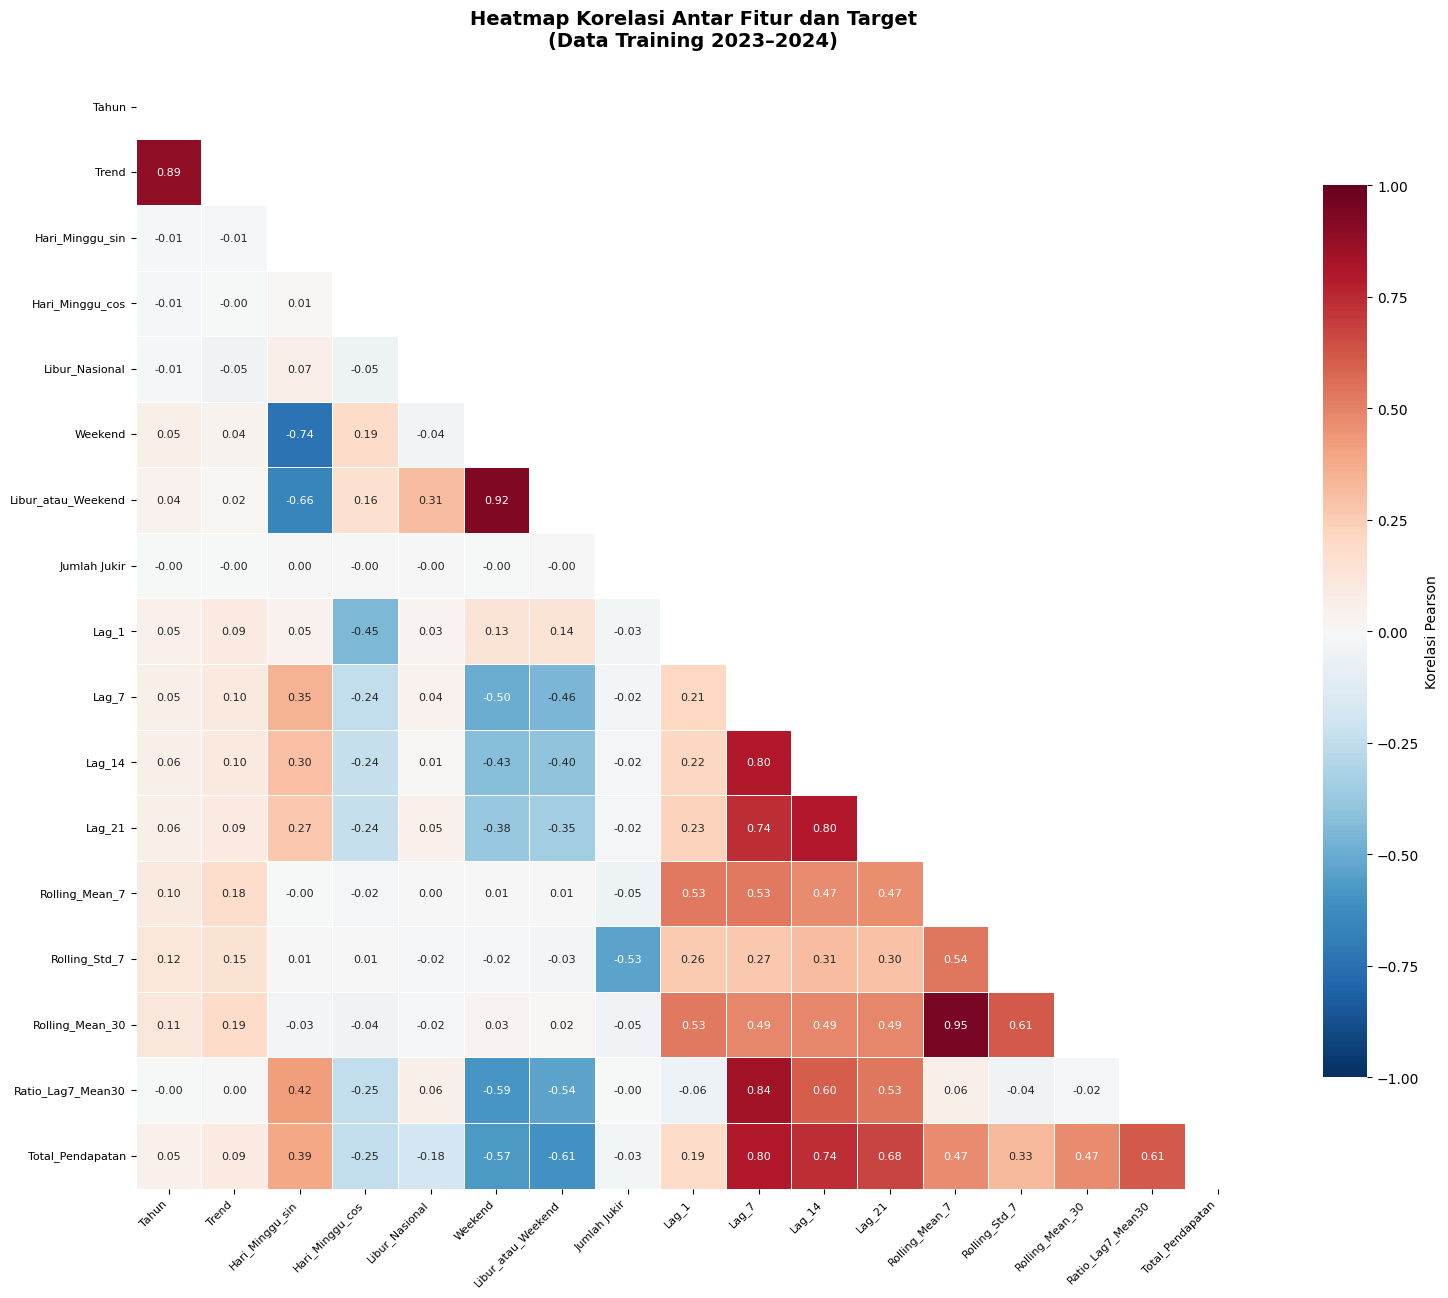


📊 Ranking Korelasi terhadap Target:


,|Korelasi Pearson|
Lag_7,0.797138
Lag_14,0.735634
Lag_21,0.676420
Ratio_Lag7_Mean30,0.612739
Libur_atau_Weekend,0.609287
Weekend,0.570696
Rolling_Mean_7,0.473124
Rolling_Mean_30,0.472313
Hari_Minggu_sin,0.387640
Rolling_Std_7,0.328015


✅ CELL 4 BERHASIL!


In [ ]:
# ============================================================
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 4 — EDA: HEATMAP KORELASI                         ║
# ╚══════════════════════════════════════════════════════════╝
# ============================================================

# ── Rayon cols tanpa Rayon_asli ──
rayon_cols = [col for col in df.columns
              if col.startswith('Rayon_') and col != 'Rayon_asli']

# ── List fitur FINAL ──
fitur = [
    'Tahun',
    'Trend',
    'Hari_Minggu_sin', 'Hari_Minggu_cos',   # r = 0.39, -0.25
    'Tgl_Kalender_sin', 'Tgl_Kalender_cos',
    'Minggu_sin', 'Minggu_cos',
    'Libur_Nasional',                        # r = -0.18
    'Weekend',                               # r = -0.57
    'Libur_atau_Weekend',                    # r = -0.61 ← terkuat
    'Jumlah Jukir',                          # r =  0.03
    'Lag_1',                                 # r =  0.19
    'Lag_7',                                 # r =  0.80 ← terkuat
    'Lag_14',                                # r =  0.74
    'Lag_21',                                # r =  0.68
    'Rolling_Mean_7',                        # r =  0.47
    'Rolling_Std_7',                         # r =  0.33
    'Rolling_Mean_30',                       # r =  0.47
    'Ratio_Lag7_Mean30',                     # r =  0.61
] + rayon_cols

target = 'Total_Pendapatan'

print(f"✅ Total fitur: {len(fitur)}")
print(f"   Lag aktif   : Lag_1, Lag_7, Lag_14, Lag_21")
print(f"   Lag dihapus : Lag_3, Lag_30")
print(f"   Rayon cols  : {rayon_cols}")

# ── Heatmap ──
df_train_eda = df[df['Tahun'] <= 2024].copy()

fitur_heatmap = [
    'Tahun', 'Trend', 'Hari_Minggu_sin', 'Hari_Minggu_cos',
    'Libur_Nasional', 'Weekend', 'Libur_atau_Weekend', 'Jumlah Jukir',
    'Lag_1',
    'Lag_7', 'Lag_14', 'Lag_21',
    'Rolling_Mean_7', 'Rolling_Std_7', 'Rolling_Mean_30',
    'Ratio_Lag7_Mean30',
    'Total_Pendapatan'
]

matriks_kor = df_train_eda[fitur_heatmap].corr()
mask        = np.triu(np.ones_like(matriks_kor, dtype=bool))

plt.figure(figsize=(16, 13))
sns.heatmap(
    matriks_kor, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Korelasi Pearson', 'shrink': 0.8},
    annot_kws={'size': 8}
)
plt.title('Heatmap Korelasi Antar Fitur dan Target\n(Data Training 2023–2024)',
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Ranking Korelasi terhadap Target:")
kor_rank = (df_train_eda[fitur_heatmap].corr()[target]
            .drop(target).abs().sort_values(ascending=False))
display(kor_rank.rename('|Korelasi Pearson|').to_frame())
print("✅ CELL 4 BERHASIL!")

# SPLIT DATA, LOG TRANSFORM & NORMALISASI

In [ ]:
# ============================================================
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 5 — SPLIT DATA, LOG TRANSFORM & NORMALISASI       ║
# ╚══════════════════════════════════════════════════════════╝
# Split: 80% Train / 20% Test (time-based, urutan waktu)
# ============================================================

# ── Split 80/20 berbasis urutan waktu ──
df_sorted  = df.sort_values('Tanggal').reset_index(drop=True)
split_idx  = int(len(df_sorted) * 0.80)
df_train   = df_sorted.iloc[:split_idx].copy().reset_index(drop=True)
df_test    = df_sorted.iloc[split_idx:].copy().reset_index(drop=True)

print(f"   Total data   : {len(df_sorted):,} baris")
print(f"   Train (80%)  : {len(df_train):,} baris ({df_train['Tanggal'].min().date()} → {df_train['Tanggal'].max().date()})")
print(f"   Test  (20%)  : {len(df_test):,}  baris ({df_test['Tanggal'].min().date()} → {df_test['Tanggal'].max().date()})")

X_train_raw = df_train[fitur].values
X_test_raw  = df_test[fitur].values

# ── Target: Log1p Transform ──
y_train_log = np.log1p(df_train[target].values).reshape(-1, 1)
y_test_log  = np.log1p(df_test[target].values).reshape(-1, 1)

# Simpan nilai asli untuk evaluasi
y_train_asli = df_train[target].values.flatten()
y_test_asli  = df_test[target].values.flatten()

print(f"\nCV target ASLI     : {np.std(y_train_asli)/np.mean(y_train_asli)*100:.1f}%")
print(f"CV target LOG      : {np.std(y_train_log)/np.mean(y_train_log)*100:.1f}%")
print("→ Log transform turunkan variasi target, SVR lebih mudah belajar!\n")

# ── Normalisasi ──
scaler_X = RobustScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(X_train_raw)
y_train = scaler_y.fit_transform(y_train_log).ravel()

X_test  = scaler_X.transform(X_test_raw)
y_test  = scaler_y.transform(y_test_log).ravel()

print("✅ CELL 5 BERHASIL!")
print(f"   Fitur        : {len(fitur)} variabel")
print(f"   Data Train   : {len(df_train):,} baris")
print(f"   Data Test    : {len(df_test):,} baris")
print(f"   Scaler X     : RobustScaler")
print(f"   Scaler y     : MinMaxScaler(log1p(target))")

   Total data   : 3,825 baris
   Train (80%)  : 3,060 baris (2023-01-31 → 2025-02-14)
   Test  (20%)  : 765  baris (2025-02-15 → 2025-07-20)

CV target ASLI     : 39.6%
CV target LOG      : 5.0%
→ Log transform turunkan variasi target, SVR lebih mudah belajar!

✅ CELL 5 BERHASIL!
   Fitur        : 25 variabel
   Data Train   : 3,060 baris
   Data Test    : 765 baris
   Scaler X     : RobustScaler
   Scaler y     : MinMaxScaler(log1p(target))


# FUNGSI EVALUASI

In [ ]:
# ============================================================
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 6 — FUNGSI EVALUASI                               ║
# ╚══════════════════════════════════════════════════════════╝
# PENTING: inverse transform pakai expm1 karena pakai log1p
# ============================================================

def inverse_pred(y_scaled):
    """Kembalikan prediksi ke skala Rupiah asli."""
    y_log  = scaler_y.inverse_transform(y_scaled.reshape(-1, 1)).flatten()
    return np.expm1(y_log)   # kebalikan log1p

def hitung_metrik(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true > 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, mape, r2

def cetak_hasil(nama, mae, rmse, mape_test, mape_train, r2, waktu):
    gap     = abs(mape_test - mape_train)
    akurasi = max(0, 100 - mape_test)
    if gap < 5:
        status = "✅ BAIK (tidak overfit)"
    elif gap < 10:
        status = "⚠️  PERLU DICEK"
    else:
        status = "❌ OVERFIT"
    print(f"\n  ┌{'─'*58}┐")
    print(f"  │  📊 {nama:<51}  │")
    print(f"  ├{'─'*58}┤")
    print(f"  │  MAE            : Rp {mae:>27,.0f}  │")
    print(f"  │  RMSE           : Rp {rmse:>27,.0f}  │")
    print(f"  │  MAPE Test      : {mape_test:>30.4f}%  │")
    print(f"  │  MAPE Train     : {mape_train:>30.4f}%  │")
    print(f"  │  Gap Overfit    : {gap:>30.4f}%  │")
    print(f"  │  R²             : {r2:>31.6f}  │")
    print(f"  │  Akurasi Model  : {akurasi:>30.2f}%  │")
    print(f"  │  Status         : {status:<32}  │")
    print(f"  │  Waktu Training : {waktu:>29.2f}s  │")
    print(f"  └{'─'*58}┘")

print("✅ CELL 6 BERHASIL!")

✅ CELL 6 BERHASIL!


# SVR

In [ ]:
# ============================================================
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 7 — MODEL 1: SVR                         ║
# ╚══════════════════════════════════════════════════════════╝
# ============================================================

print("=" * 60)
print("  MODEL 1 — SVR")
print("=" * 60)

t0 = time.time()

svr_baseline = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')
svr_baseline.fit(X_train, y_train)

y_pred_base_train = inverse_pred(svr_baseline.predict(X_train))
y_pred_base_test  = inverse_pred(svr_baseline.predict(X_test))

lama_base = time.time() - t0

mae_base, rmse_base, mape_base_test,  r2_base  = hitung_metrik(y_test_asli,  y_pred_base_test)
_,        _,         mape_base_train, _         = hitung_metrik(y_train_asli, y_pred_base_train)

cetak_hasil("SVR Baseline", mae_base, rmse_base,
            mape_base_test, mape_base_train, r2_base, lama_base)

  MODEL 1 — SVR BASELINE

  ┌──────────────────────────────────────────────────────────┐
  │  📊 SVR Baseline                                         │
  ├──────────────────────────────────────────────────────────┤
  │  MAE            : Rp                     369,655  │
  │  RMSE           : Rp                     451,420  │
  │  MAPE Test      :                        25.1129%  │
  │  MAPE Train     :                        22.6831%  │
  │  Gap Overfit    :                         2.4298%  │
  │  R²             :                        0.520081  │
  │  Akurasi Model  :                          74.89%  │
  │  Status         : ✅ BAIK (tidak overfit)            │
  │  Waktu Training :                          0.18s  │
  └──────────────────────────────────────────────────────────┘


# SVR + GRID SEARCH

In [ ]:
# ============================================================
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 8 — MODEL 2: SVR + GRID SEARCH                    ║
# ╚══════════════════════════════════════════════════════════╝
# ============================================================

print("=" * 60)
print("  MODEL 2 — SVR + GRID SEARCH")
print("=" * 60)

param_grid = {
    'C'      : [10, 50, 100, 150, 200],
    'epsilon': [0.001, 0.005, 0.01, 0.05],
    'gamma'  : ['scale', 0.001, 0.01, 0.05]
}

N_SPLITS_GS = 5
tscv_gs     = TimeSeriesSplit(n_splits=N_SPLITS_GS)
candidates  = list(ParameterGrid(param_grid))
total_fit   = len(candidates) * N_SPLITS_GS
best_score  = float('inf')
best_params = None
all_results = []

print(f"  Grid C       : {param_grid['C']}")
print(f"  Grid epsilon : {param_grid['epsilon']}")
print(f"  Grid gamma   : {param_grid['gamma']}")
print(f"  Kombinasi    : {len(candidates)}")
print(f"  CV Fold      : {N_SPLITS_GS}")
print(f"  Total fit    : {len(candidates)} × {N_SPLITS_GS} = {total_fit}")
print(f"  Metrik CV    : RMSE (Root Mean Squared Error)")
print("-" * 60)

t0   = time.time()
pbar = tqdm(total=total_fit,
            bar_format="  {l_bar}{bar:28}{r_bar}",
            unit="fit")

for combo_idx, params in enumerate(candidates, 1):
    fold_scores = []
    fold_start  = time.time()

    for fold_idx, (tr_idx, val_idx) in enumerate(tscv_gs.split(X_train), 1):
        m = SVR(kernel='rbf', cache_size=500, **params)
        m.fit(X_train[tr_idx], y_train[tr_idx])
        rmse = np.sqrt(mean_squared_error(y_train[val_idx], m.predict(X_train[val_idx])))
        fold_scores.append(rmse)

        pbar.set_description(
            f"  [{combo_idx:>3}/{len(candidates)}] "
            f"C={str(params['C']):>4} | "
            f"ε={str(params['epsilon']):>4} | "
            f"γ={str(params['gamma']):>5} | "
            f"fold {fold_idx}/{N_SPLITS_GS}"
        )
        pbar.set_postfix(
            fold_RMSE = f"{rmse:.5f}",
            best_RMSE = f"{best_score:.5f}"
        )
        pbar.update(1)

    avg        = float(np.mean(fold_scores))
    fold_time  = time.time() - fold_start
    is_best    = avg < best_score

    all_results.append({
        'params'     : params,
        'score'      : avg,
        'fold_scores': fold_scores,
        'std'        : float(np.std(fold_scores)),
        'waktu'      : fold_time,
    })

    if is_best:
        best_score  = avg
        best_params = params

    # ── Print detail tiap kombinasi ──
    status = "🏆 BEST BARU!" if is_best else ""
    print(f"\n  [{combo_idx:>3}/{len(candidates)}] "
          f"C={str(params['C']):>4} | "
          f"ε={str(params['epsilon']):>4} | "
          f"γ={str(params['gamma']):>5}  {status}")
    print(f"  Fold RMSE : "
          f"{' | '.join([f'fold{i+1}={s:.5f}' for i,s in enumerate(fold_scores)])}")
    print(f"  Avg RMSE  : {avg:.6f}  ±{np.std(fold_scores):.6f}  "
          f"({fold_time:.1f}s)  "
          f"{'↓ lebih baik dari sebelumnya' if is_best else f'best masih {best_score:.6f}'}")

pbar.set_description("  ✅ Grid Search Selesai!")
pbar.close()

# ─────────────────────────────────────────────
# Training model final
# ─────────────────────────────────────────────
svr_gs = SVR(kernel='rbf', cache_size=500, **best_params)
svr_gs.fit(X_train, y_train)

y_pred_gs_train = inverse_pred(svr_gs.predict(X_train))
y_pred_gs_test  = inverse_pred(svr_gs.predict(X_test))

lama_gs = time.time() - t0

mae_gs, rmse_gs, mape_gs_test,  r2_gs  = hitung_metrik(y_test_asli,  y_pred_gs_test)
_,      _,       mape_gs_train, _       = hitung_metrik(y_train_asli, y_pred_gs_train)

# ─────────────────────────────────────────────
# Ringkasan hasil
# ─────────────────────────────────────────────
sorted_results = sorted(all_results, key=lambda x: x['score'])

print(f"\n{'='*60}")
print(f"  📊  RINGKASAN GRID SEARCH")
print(f"{'='*60}")
print(f"  Total kombinasi : {len(candidates)}")
print(f"  Total waktu     : {lama_gs:.1f}s")
print(f"  Waktu per combo : ~{lama_gs/len(candidates):.1f}s")

print(f"\n  📋  TOP 5 KOMBINASI TERBAIK:")
print(f"  {'Rank':<5} {'C':>6} {'ε':>6} {'γ':>7} {'Avg RMSE':>12} {'Std RMSE':>12}")
print(f"  {'-'*55}")
for rank, res in enumerate(sorted_results[:5], 1):
    p = res['params']
    marker = " ← BEST" if rank == 1 else ""
    print(f"  {rank:<5} {str(p['C']):>6} {str(p['epsilon']):>6} "
          f"{str(p['gamma']):>7} {res['score']:>12.6f} "
          f"{res['std']:>12.6f}{marker}")

print(f"\n  ❌  BOTTOM 3 KOMBINASI TERBURUK:")
print(f"  {'Rank':<5} {'C':>6} {'ε':>6} {'γ':>7} {'Avg RMSE':>12}")
print(f"  {'-'*45}")
for rank, res in enumerate(sorted_results[-3:], len(candidates)-2):
    p = res['params']
    print(f"  {rank:<5} {str(p['C']):>6} {str(p['epsilon']):>6} "
          f"{str(p['gamma']):>7} {res['score']:>12.6f}")

print(f"\n  🏆  PARAMETER TERBAIK:")
print(f"      C        : {best_params['C']}")
print(f"      Epsilon  : {best_params['epsilon']}")
print(f"      Gamma    : {best_params['gamma']}")
print(f"      RMSE CV  : {best_score:.6f}")

cetak_hasil("SVR + Grid Search", mae_gs, rmse_gs,
            mape_gs_test, mape_gs_train, r2_gs, lama_gs)

  MODEL 2 — SVR + GRID SEARCH
  Grid C       : [10, 50, 100, 150, 200]
  Grid epsilon : [0.001, 0.005, 0.01, 0.05]
  Grid gamma   : ['scale', 0.001, 0.01, 0.05]
  Kombinasi    : 80
  CV Fold      : 5
  Total fit    : 80 × 5 = 400
  Metrik CV    : RMSE (Root Mean Squared Error)
------------------------------------------------------------


    0%|                            | 0/400 [00:00<?, ?fit/s]


  [  1/80] C=  10 | ε=0.001 | γ=scale  🏆 BEST BARU!
  Fold RMSE : fold1=0.07618 | fold2=0.08336 | fold3=0.07837 | fold4=0.04750 | fold5=0.05970
  Avg RMSE  : 0.069024  ±0.013373  (19.2s)  ↓ lebih baik dari sebelumnya

  [  2/80] C=  10 | ε=0.001 | γ=0.001  
  Fold RMSE : fold1=0.10869 | fold2=0.10415 | fold3=0.11681 | fold4=0.04370 | fold5=0.06641
  Avg RMSE  : 0.087951  ±0.028096  (1.7s)  best masih 0.069024

  [  3/80] C=  10 | ε=0.001 | γ= 0.01  
  Fold RMSE : fold1=0.08714 | fold2=0.08720 | fold3=0.09284 | fold4=0.04381 | fold5=0.05578
  Avg RMSE  : 0.073354  ±0.019714  (7.9s)  best masih 0.069024

  [  4/80] C=  10 | ε=0.001 | γ= 0.05  🏆 BEST BARU!
  Fold RMSE : fold1=0.07586 | fold2=0.08227 | fold3=0.07778 | fold4=0.04596 | fold5=0.05904
  Avg RMSE  : 0.068181  ±0.013615  (18.8s)  ↓ lebih baik dari sebelumnya

  [  5/80] C=  10 | ε=0.005 | γ=scale  
  Fold RMSE : fold1=0.07636 | fold2=0.08616 | fold3=0.07673 | fold4=0.04581 | fold5=0.06045
  Avg RMSE  : 0.069099  ±0.014278  (8.9

# SVR + GREY WOLF OPTIMIZER

In [ ]:
print("=" * 60)
print("  MODEL 3 — SVR + GREY WOLF OPTIMIZER (GWO)")
print("=" * 60)

# ─────────────────────────────────────────────
# ✅ HYPERPARAMETER GWO v5
# ─────────────────────────────────────────────
# Strategi: micro search antara zona v2 dan v4
#
# v2 best → C=199.5, ε=0.000316, γ=0.00677  → MAPE 12.99% ✅ terbaik
# v4 best → C=199.5, ε=0.005012, γ=0.00481  → MAPE 13.04%
#
# C dikunci [180, 250] karena selalu optimal di sini
# ε zona tengah → [0.0002, 0.006]
# γ zona tengah → [0.004, 0.012]

NUM_WOLVES    = 12        # Lebih banyak wolf untuk coverage zona kecil
MAX_ITER      = 20        # Lebih banyak iterasi
DIM           = 3
N_SPLITS_GWO  = 3
EARLY_STOP    = 8
RESTART_FRAC  = 0.30
PERTURB_STD   = 0.08      # Lebih kecil — zona sempit, perturb halus
RESTART_EVERY = 3

# Search space dipersempit & zona spesifik
# C     : [180, 250]   → log10 = [2.255, 2.398]
# ε     : [0.0002, 0.006] → log10 = [-3.699, -2.222]
# γ     : [0.004, 0.012]  → log10 = [-2.398, -1.921]
LB = np.array([2.255,  -3.699,  -2.398])   # C=180,    ε=0.0002, γ=0.004
UB = np.array([2.398,  -2.222,  -1.921])   # C=250,    ε=0.0063, γ=0.012

print(f"  Wolves     : {NUM_WOLVES}")
print(f"  Iterasi    : {MAX_ITER}")
print(f"  CV Fold    : {N_SPLITS_GWO}")
print(f"  Metrik CV  : RMSE (Root Mean Squared Error)")
print(f"  Early Stop : {EARLY_STOP} iterasi tanpa perbaikan")
print(f"  Restart    : {int(RESTART_FRAC*100)}% wolf setiap {RESTART_EVERY} iter stagnasi")
print(f"  C          : [10^{LB[0]:.3f}, 10^{UB[0]:.3f}] = [{10**LB[0]:.1f}, {10**UB[0]:.1f}]")
print(f"  Epsilon    : [10^{LB[1]:.3f}, 10^{UB[1]:.3f}] = [{10**LB[1]:.5f}, {10**UB[1]:.5f}]")
print(f"  Gamma      : [10^{LB[2]:.3f}, 10^{UB[2]:.3f}] = [{10**LB[2]:.5f}, {10**UB[2]:.5f}]")
print(f"  Total Eval : {NUM_WOLVES} × {MAX_ITER} × {N_SPLITS_GWO} = "
      f"{NUM_WOLVES*MAX_ITER*N_SPLITS_GWO} fit (maks)")
print("-" * 60)

# ─────────────────────────────────────────────
# ✅ Warm start: tanam 2 wolf di titik referensi v2 & v4
# ─────────────────────────────────────────────
np.random.seed(42)
positions = np.random.uniform(0, 1, (NUM_WOLVES, DIM)) * (UB - LB) + LB

# Wolf 0 → titik terbaik v2 (MAPE 12.99%)
REF_C_v2     = np.log10(199.5)
REF_EPS_v2   = np.log10(0.000316)
REF_GAMMA_v2 = np.log10(0.00677)
positions[0] = np.clip([REF_C_v2, REF_EPS_v2, REF_GAMMA_v2], LB, UB)
print(f"  Wolf[ 0] warm-start v2: C=199.5, ε=0.000316, γ=0.00677 (MAPE 12.99%)")

# Wolf 1 → titik terbaik v4 (MAPE 13.04%)
REF_C_v4     = np.log10(199.5)
REF_EPS_v4   = np.log10(0.005012)
REF_GAMMA_v4 = np.log10(0.00481)
positions[1] = np.clip([REF_C_v4, REF_EPS_v4, REF_GAMMA_v4], LB, UB)
print(f"  Wolf[ 1] warm-start v4: C=199.5, ε=0.005012, γ=0.00481 (MAPE 13.04%)")

# Wolf 2 → titik tengah interpolasi v2 & v4
REF_C_mid     = np.log10(199.5)
REF_EPS_mid   = np.log10((0.000316 + 0.005012) / 2)   # ε tengah ~0.00266
REF_GAMMA_mid = np.log10((0.00677  + 0.00481)  / 2)   # γ tengah ~0.00579
positions[2] = np.clip([REF_C_mid, REF_EPS_mid, REF_GAMMA_mid], LB, UB)
print(f"  Wolf[ 2] warm-start mid: C=199.5, ε={10**REF_EPS_mid:.5f}, γ={10**REF_GAMMA_mid:.5f} (interpolasi)")

for wi in range(3, NUM_WOLVES):
    print(f"  Wolf[{wi:>2}] init     : C={10**positions[wi][0]:.3f}, "
          f"ε={10**positions[wi][1]:.6f}, γ={10**positions[wi][2]:.6f}")
print("-" * 60)

# ─────────────────────────────────────────────
# ✅ Setup alpha, beta, delta
# ─────────────────────────────────────────────
alpha_pos = np.zeros(DIM);  alpha_score = float("inf")
beta_pos  = np.zeros(DIM);  beta_score  = float("inf")
delta_pos = np.zeros(DIM);  delta_score = float("inf")

convergence_curve = []
iter_best_log     = []

# ✅ TimeSeriesSplit dengan gap
tscv_gwo = TimeSeriesSplit(n_splits=N_SPLITS_GWO, gap=3)

# ─────────────────────────────────────────────
# ✅ Fungsi fitness
# ─────────────────────────────────────────────
def fitness_gwo(pos):
    model = SVR(
        kernel    = 'rbf',
        C         = 10 ** pos[0],
        epsilon   = 10 ** pos[1],
        gamma     = 10 ** pos[2],
        cache_size= 2000
    )
    scores = cross_val_score(
        model, X_train, y_train,
        cv      = tscv_gwo,
        scoring = 'neg_root_mean_squared_error',
        n_jobs  = -1
    )
    return -scores.mean()

# ─────────────────────────────────────────────
# ✅ Loop GWO utama
# ─────────────────────────────────────────────
t0         = time.time()
total_eval = NUM_WOLVES * MAX_ITER
pbar       = tqdm(
    total      = total_eval,
    bar_format = "  {l_bar}{bar:25}{r_bar}",
    unit       = "eval"
)

no_improve_count = 0
prev_alpha_score = float("inf")
restart_log      = []

for t in range(MAX_ITER):
    iter_start   = time.time()
    wolves_score = []

    # ── Evaluasi tiap wolf ──
    for i in range(NUM_WOLVES):
        fit = fitness_gwo(positions[i])
        wolves_score.append(fit)

        # Update hierarki alpha / beta / delta
        if fit < alpha_score:
            delta_score, delta_pos = beta_score,  beta_pos.copy()
            beta_score,  beta_pos  = alpha_score, alpha_pos.copy()
            alpha_score, alpha_pos = fit,         positions[i].copy()
        elif fit < beta_score:
            delta_score, delta_pos = beta_score, beta_pos.copy()
            beta_score,  beta_pos  = fit,        positions[i].copy()
        elif fit < delta_score:
            delta_score, delta_pos = fit, positions[i].copy()

        # Update progress bar
        elapsed = time.time() - t0
        done    = t * NUM_WOLVES + (i + 1)
        eta     = (elapsed / done) * (total_eval - done) if done else 0
        pbar.set_description(f"  Iter {t+1:>2}/{MAX_ITER} | Wolf {i+1:>2}/{NUM_WOLVES}")
        pbar.set_postfix(
            alpha_RMSE = f"{alpha_score:.5f}",
            C          = f"{10**alpha_pos[0]:.3f}",
            eps        = f"{10**alpha_pos[1]:.6f}",
            gamma      = f"{10**alpha_pos[2]:.5f}",
            ETA        = f"~{eta:.0f}s"
        )
        pbar.update(1)

    # ── Update posisi wolf (GWO standar) ──
    a = 2 - t * (2 / MAX_ITER)
    for i in range(NUM_WOLVES):
        for j in range(DIM):
            r1, r2 = np.random.rand(), np.random.rand()
            X1 = alpha_pos[j] - (2*a*r1 - a) * abs(2*r2*alpha_pos[j] - positions[i,j])
            r1, r2 = np.random.rand(), np.random.rand()
            X2 = beta_pos[j]  - (2*a*r1 - a) * abs(2*r2*beta_pos[j]  - positions[i,j])
            r1, r2 = np.random.rand(), np.random.rand()
            X3 = delta_pos[j] - (2*a*r1 - a) * abs(2*r2*delta_pos[j] - positions[i,j])
            positions[i,j] = np.clip((X1 + X2 + X3) / 3.0, LB[j], UB[j])

    # ── Simpan kurva konvergensi ──
    convergence_curve.append(alpha_score)

    # ── Cek improvement ──
    improved  = alpha_score < prev_alpha_score - 1e-6
    iter_time = time.time() - iter_start

    iter_best_log.append({
        'iter'       : t + 1,
        'alpha_rmse' : alpha_score,
        'beta_rmse'  : beta_score,
        'delta_rmse' : delta_score,
        'wolf_min'   : min(wolves_score),
        'wolf_mean'  : np.mean(wolves_score),
        'wolf_max'   : max(wolves_score),
        'a'          : a,
        'C'          : 10**alpha_pos[0],
        'eps'        : 10**alpha_pos[1],
        'gamma'      : 10**alpha_pos[2],
        'waktu_iter' : iter_time,
        'improved'   : improved,
    })

    # ── Print ringkasan iterasi ──
    status = "✅ MEMBAIK" if improved else "⏸  stagnasi"
    print(f"\n  {'─'*58}")
    print(f"  Iter {t+1:>2}/{MAX_ITER}  [{status}]  a={a:.3f}  waktu={iter_time:.1f}s")
    print(f"  α RMSE={alpha_score:.6f} | β RMSE={beta_score:.6f} | δ RMSE={delta_score:.6f}")
    print(f"  α C={10**alpha_pos[0]:.4f} | ε={10**alpha_pos[1]:.7f} | γ={10**alpha_pos[2]:.6f}")
    print(f"  Wolf RMSE → min={min(wolves_score):.5f} | "
          f"mean={np.mean(wolves_score):.5f} | "
          f"max={max(wolves_score):.5f}")

    # ── Early stopping & random restart ──
    if improved:
        no_improve_count = 0
        prev_alpha_score = alpha_score
    else:
        no_improve_count += 1
        print(f"  ⚠️  Tidak ada perbaikan: {no_improve_count}/{EARLY_STOP}")

        # ✅ Random Restart
        if no_improve_count % RESTART_EVERY == 0:
            n_restart   = max(1, int(NUM_WOLVES * RESTART_FRAC))
            restart_idx = np.random.choice(NUM_WOLVES, n_restart, replace=False)
            restarted   = 0
            for idx in restart_idx:
                if np.allclose(positions[idx], alpha_pos, atol=1e-4):
                    continue
                noise = np.random.normal(0, PERTURB_STD, DIM)
                positions[idx] = np.clip(alpha_pos + noise, LB, UB)
                restarted += 1
            restart_log.append({'iter': t+1, 'n_restart': restarted})
            print(f"  🔄  Random Restart: {restarted} wolf diperturb di sekitar alpha")

        # ✅ Early Stopping
        if no_improve_count >= EARLY_STOP:
            remaining = (MAX_ITER - t - 1) * NUM_WOLVES
            pbar.update(remaining)
            print(f"\n  ⏹️  EARLY STOPPING di iterasi {t+1}/{MAX_ITER}")
            print(f"       Tidak ada perbaikan selama {EARLY_STOP} iterasi berturut")
            break

pbar.set_description("  ✅ GWO v5 Selesai!")
pbar.close()

# ─────────────────────────────────────────────
# Ringkasan konvergensi
# ─────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  📈  RINGKASAN KONVERGENSI GWO v5 MICRO SEARCH")
print(f"{'='*60}")
print(f"  Total iterasi    : {len(convergence_curve)}/{MAX_ITER}")
print(f"  RMSE awal        : {convergence_curve[0]:.6f}")
print(f"  RMSE akhir       : {convergence_curve[-1]:.6f}")
perbaikan = (convergence_curve[0] - convergence_curve[-1]) / convergence_curve[0] * 100
print(f"  Perbaikan total  : {perbaikan:.2f}%")
iter_improve = sum(1 for x in iter_best_log if x['improved'])
print(f"  Iterasi membaik  : {iter_improve}/{len(convergence_curve)}")
print(f"  Total restart    : {len(restart_log)}x "
      f"({sum(r['n_restart'] for r in restart_log)} wolf)")
print(f"  Waktu total      : {(time.time()-t0)/60:.1f} menit")
print(f"  Waktu per iter   : ~{np.mean([x['waktu_iter'] for x in iter_best_log]):.1f}s")
print(f"{'='*60}")

# ─────────────────────────────────────────────
# Perbandingan dengan v2 & v4
# ─────────────────────────────────────────────
print(f"\n  📊  PERBANDINGAN KANDIDAT TERBAIK:")
print(f"  {'Versi':<10} {'C':>8} {'Epsilon':>10} {'Gamma':>8} {'RMSE CV':>10}")
print(f"  {'─'*50}")
print(f"  {'GWO v2':<10} {199.5:>8.2f} {0.000316:>10.6f} {0.00677:>8.5f} {'(lihat MAPE)':>10}")
print(f"  {'GWO v4':<10} {199.5:>8.2f} {0.005012:>10.6f} {0.00481:>8.5f} {'(lihat MAPE)':>10}")
print(f"  {'GWO v5':<10} {10**alpha_pos[0]:>8.2f} {10**alpha_pos[1]:>10.6f} {10**alpha_pos[2]:>8.5f} {alpha_score:>10.6f}")
print(f"  {'─'*50}")

# ─────────────────────────────────────────────
# Training model final
# ─────────────────────────────────────────────
BEST_C     = 10 ** alpha_pos[0]
BEST_EPS   = 10 ** alpha_pos[1]
BEST_GAMMA = 10 ** alpha_pos[2]

print(f"\n  🏆  Parameter GWO v5 Terbaik:")
print(f"      C       : {BEST_C:.6f}")
print(f"      Epsilon : {BEST_EPS:.8f}")
print(f"      Gamma   : {BEST_GAMMA:.7f}")
print(f"      RMSE CV : {convergence_curve[-1]:.6f}")
print(f"\n  🔧  Training model final...")

svr_gwo = SVR(
    kernel    = 'rbf',
    C         = BEST_C,
    epsilon   = BEST_EPS,
    gamma     = BEST_GAMMA,
    cache_size= 2000
)
svr_gwo.fit(X_train, y_train)

y_pred_gwo_train = inverse_pred(svr_gwo.predict(X_train))
y_pred_gwo_test  = inverse_pred(svr_gwo.predict(X_test))

lama_gwo = time.time() - t0

mae_gwo, rmse_gwo, mape_gwo_test,  r2_gwo = hitung_metrik(y_test_asli,  y_pred_gwo_test)
_,       _,        mape_gwo_train, _       = hitung_metrik(y_train_asli, y_pred_gwo_train)

cetak_hasil("SVR + GWO v5 Micro", mae_gwo, rmse_gwo,
            mape_gwo_test, mape_gwo_train, r2_gwo, lama_gwo)

  MODEL 3 — SVR + GREY WOLF OPTIMIZER (GWO) v5 MICRO SEARCH
  Wolves     : 12
  Iterasi    : 20
  CV Fold    : 3
  Metrik CV  : RMSE (Root Mean Squared Error)
  Early Stop : 8 iterasi tanpa perbaikan
  Restart    : 30% wolf setiap 3 iter stagnasi
  C          : [10^2.255, 10^2.398] = [179.9, 250.0]
  Epsilon    : [10^-3.699, 10^-2.222] = [0.00020, 0.00600]
  Gamma      : [10^-2.398, 10^-1.921] = [0.00400, 0.01199]
  Total Eval : 12 × 20 × 3 = 720 fit (maks)
------------------------------------------------------------
  Wolf[ 0] warm-start v2: C=199.5, ε=0.000316, γ=0.00677 (MAPE 12.99%)
  Wolf[ 1] warm-start v4: C=199.5, ε=0.005012, γ=0.00481 (MAPE 13.04%)
  Wolf[ 2] warm-start mid: C=199.5, ε=0.00266, γ=0.00579 (interpolasi)
  Wolf[ 3] init     : C=227.119, ε=0.000214, γ=0.011605
  Wolf[ 4] init     : C=236.613, ε=0.000412, γ=0.004883
  Wolf[ 5] init     : C=191.085, ε=0.000563, γ=0.007117
  Wolf[ 6] init     : C=207.381, ε=0.000538, γ=0.007832
  Wolf[ 7] init     : C=188.342, ε=0.000

    0%|                         | 0/240 [00:00<?, ?eval/s]


  ──────────────────────────────────────────────────────────
  Iter  1/20  [✅ MEMBAIK]  a=2.000  waktu=400.8s
  α RMSE=0.067408 | β RMSE=0.067846 | δ RMSE=0.067947
  α C=199.5000 | ε=0.0050120 | γ=0.004810
  Wolf RMSE → min=0.06741 | mean=0.07011 | max=0.07766

  ──────────────────────────────────────────────────────────
  Iter  2/20  [⏸  stagnasi]  a=1.900  waktu=256.0s
  α RMSE=0.067408 | β RMSE=0.067719 | δ RMSE=0.067719
  α C=199.5000 | ε=0.0050120 | γ=0.004810
  Wolf RMSE → min=0.06772 | mean=0.07021 | max=0.08351
  ⚠️  Tidak ada perbaikan: 1/8

  ──────────────────────────────────────────────────────────
  Iter  3/20  [⏸  stagnasi]  a=1.800  waktu=230.5s
  α RMSE=0.067408 | β RMSE=0.067446 | δ RMSE=0.067719
  α C=199.5000 | ε=0.0050120 | γ=0.004810
  Wolf RMSE → min=0.06745 | mean=0.07019 | max=0.07759
  ⚠️  Tidak ada perbaikan: 2/8

  ──────────────────────────────────────────────────────────
  Iter  4/20  [⏸  stagnasi]  a=1.700  waktu=239.8s
  α RMSE=0.067408 | β RMSE=0.067446

# GRAFIK KONVERGENSI

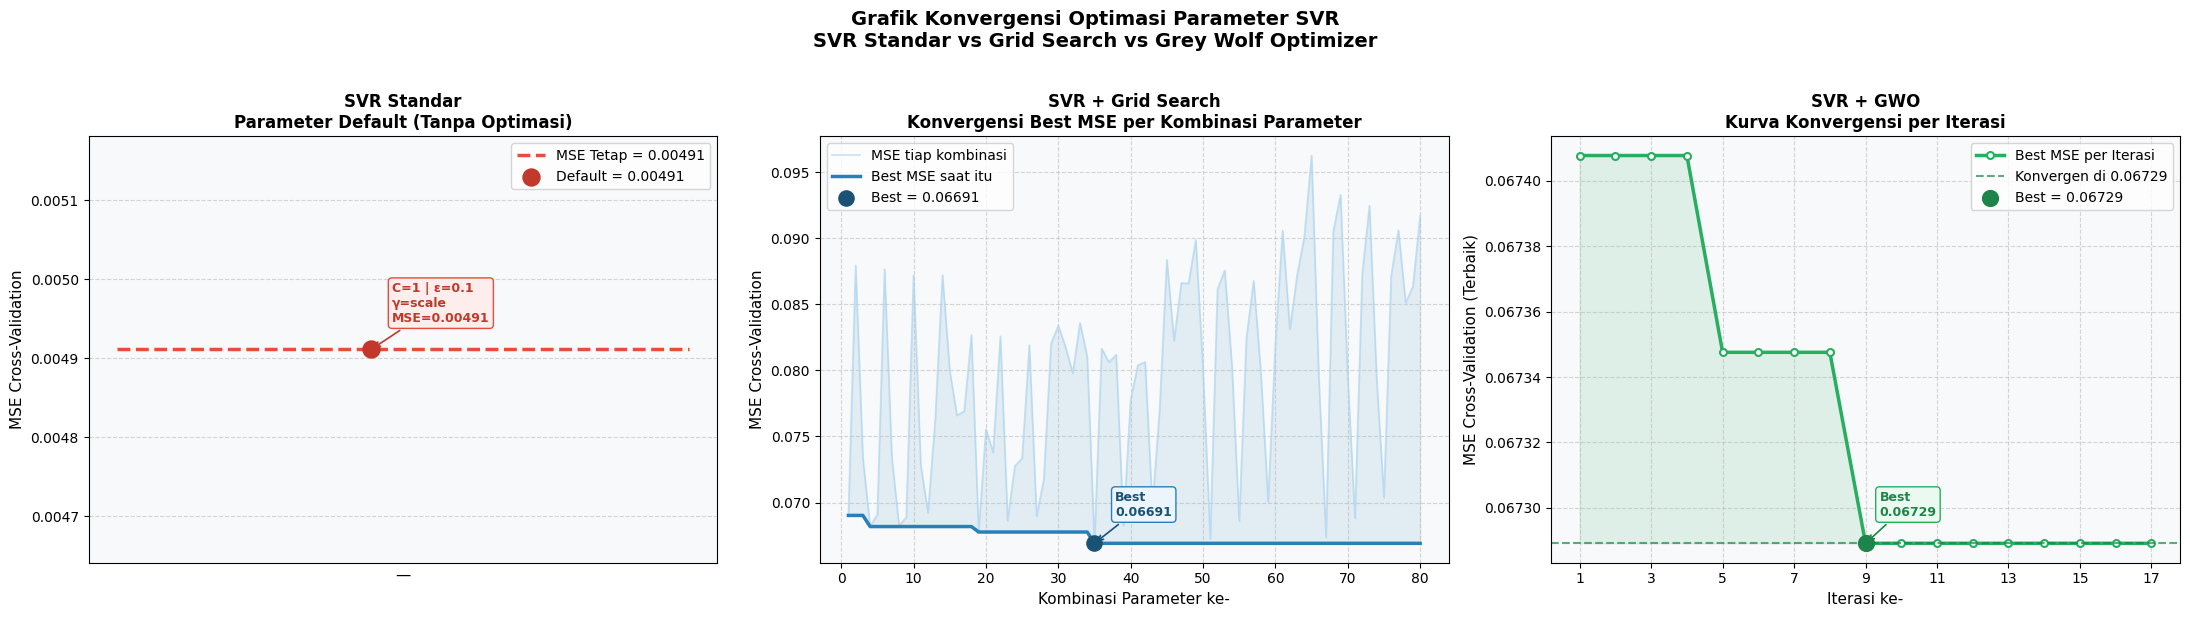

✅ CELL 10 BERHASIL: Grafik Konvergensi 3 Model selesai!


In [ ]:
# ============================================================
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 10 — GRAFIK KONVERGENSI 3 MODEL                   ║
# ║  SVR Standar + Grid Search + GWO                        ║
# ╚══════════════════════════════════════════════════════════╝
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

if 'all_results' not in globals() or 'convergence_curve' not in globals():
    print("❌ ERROR: Data 'all_results' atau 'convergence_curve' tidak ditemukan.")
    print("Silakan jalankan CELL 8 (Grid Search) dan CELL 9 (GWO) terlebih dahulu.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    fig.suptitle('Grafik Konvergensi Optimasi Parameter SVR\n'
                 'SVR Standar vs Grid Search vs Grey Wolf Optimizer',
                 fontsize=14, fontweight='bold', y=1.02)

    # ─────────────────────────────────────────────────────
    # PANEL 1 — SVR STANDAR: Parameter Default (C=1, ε=0.1, γ=scale)
    # Ditampilkan sebagai garis horizontal (nilai tetap, tidak ada proses search)
    # ─────────────────────────────────────────────────────
    ax0 = axes[0]

    # Ambil MSE baseline dari model standar (pakai y_train & X_train)
    from sklearn.metrics import mean_squared_error
    mse_baseline = mean_squared_error(y_train, svr_baseline.predict(X_train))

    # Tampilkan sebagai garis datar — tidak ada iterasi/kombinasi
    x_base = np.arange(1, 11)  # 10 titik dummy biar keliatan garisnya
    y_base = np.full(10, mse_baseline)

    ax0.plot(x_base, y_base,
             color='#E74C3C', lw=2.5, linestyle='--',
             label=f'MSE Tetap = {mse_baseline:.5f}')
    ax0.scatter([5], [mse_baseline],
                color='#C0392B', s=150, zorder=6,
                label=f'Default = {mse_baseline:.5f}')
    ax0.annotate(f'C=1 | ε=0.1\nγ=scale\nMSE={mse_baseline:.5f}',
                 xy=(5, mse_baseline),
                 xytext=(15, 20), textcoords='offset points',
                 fontsize=9, fontweight='bold', color='#C0392B',
                 arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.2),
                 bbox=dict(boxstyle='round,pad=0.3', fc='#FDEDEC', ec='#E74C3C'))

    ax0.set_title('SVR Standar\nParameter Default (Tanpa Optimasi)',
                  fontsize=12, fontweight='bold')
    ax0.set_xlabel('—', fontsize=11)
    ax0.set_ylabel('MSE Cross-Validation', fontsize=11)
    ax0.set_xticks([])
    ax0.legend(fontsize=10)
    ax0.grid(True, linestyle='--', alpha=0.5)
    ax0.set_facecolor('#F8F9FA')

    # ─────────────────────────────────────────────────────
    # PANEL 2 — SVR + GRID SEARCH: Running Best MSE
    # ─────────────────────────────────────────────────────
    ax1 = axes[1]

    semua_skor   = [r['score'] for r in all_results]
    running_best = np.minimum.accumulate(semua_skor)
    kombinasi_ke = np.arange(1, len(running_best) + 1)

    ax1.plot(kombinasi_ke, semua_skor,
             color='#AED6F1', lw=1.2, alpha=0.7,
             label='MSE tiap kombinasi')
    ax1.plot(kombinasi_ke, running_best,
             color='#2980B9', lw=2.5,
             label='Best MSE saat itu')
    ax1.fill_between(kombinasi_ke, semua_skor, running_best,
                     alpha=0.10, color='#2980B9')

    best_idx = int(np.argmin(semua_skor))
    best_val = semua_skor[best_idx]
    ax1.scatter([best_idx + 1], [best_val],
                color='#1A5276', s=120, zorder=6,
                label=f'Best = {best_val:.5f}')
    ax1.annotate(f'Best\n{best_val:.5f}',
                 xy=(best_idx + 1, best_val),
                 xytext=(15, 20), textcoords='offset points',
                 fontsize=9, fontweight='bold', color='#1A5276',
                 arrowprops=dict(arrowstyle='->', color='#1A5276', lw=1.2),
                 bbox=dict(boxstyle='round,pad=0.3', fc='#EBF5FB', ec='#2980B9'))

    ax1.set_title('SVR + Grid Search\nKonvergensi Best MSE per Kombinasi Parameter',
                  fontsize=12, fontweight='bold')
    ax1.set_xlabel('Kombinasi Parameter ke-', fontsize=11)
    ax1.set_ylabel('MSE Cross-Validation', fontsize=11)
    ax1.legend(fontsize=10)
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.set_facecolor('#F8F9FA')

    # ─────────────────────────────────────────────────────
    # PANEL 3 — SVR + GWO: Kurva Konvergensi per Iterasi
    # ─────────────────────────────────────────────────────
    ax2 = axes[2]

    iterasi   = np.arange(1, len(convergence_curve) + 1)
    best_conv = min(convergence_curve)
    best_iter = int(np.argmin(convergence_curve)) + 1

    ax2.plot(iterasi, convergence_curve,
             color='#27AE60', lw=2.5,
             marker='o', ms=5,
             markerfacecolor='white',
             markeredgecolor='#27AE60', markeredgewidth=1.5,
             label='Best MSE per Iterasi')
    ax2.fill_between(iterasi, convergence_curve, best_conv,
                     alpha=0.12, color='#27AE60')
    ax2.axhline(best_conv, color='#1E8449', linestyle='--',
                lw=1.5, alpha=0.7,
                label=f'Konvergen di {best_conv:.5f}')

    ax2.scatter([best_iter], [best_conv],
                color='#1E8449', s=130, zorder=6,
                label=f'Best = {best_conv:.5f}')
    ax2.annotate(f'Best\n{best_conv:.5f}',
                 xy=(best_iter, best_conv),
                 xytext=(10, 20), textcoords='offset points',
                 fontsize=9, fontweight='bold', color='#1E8449',
                 arrowprops=dict(arrowstyle='->', color='#1E8449', lw=1.2),
                 bbox=dict(boxstyle='round,pad=0.3', fc='#EAFAF1', ec='#27AE60'))

    ax2.set_title('SVR + GWO\nKurva Konvergensi per Iterasi',
                  fontsize=12, fontweight='bold')
    ax2.set_xlabel('Iterasi ke-', fontsize=11)
    ax2.set_ylabel('MSE Cross-Validation (Terbaik)', fontsize=11)
    ax2.set_xticks(range(1, len(convergence_curve) + 1, 2))
    ax2.legend(fontsize=10)
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.set_facecolor('#F8F9FA')

    plt.tight_layout()
    plt.savefig('konvergensi_3model.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ CELL 10 BERHASIL: Grafik Konvergensi 3 Model selesai!")

# SCATTER PLOT 3 MODEL

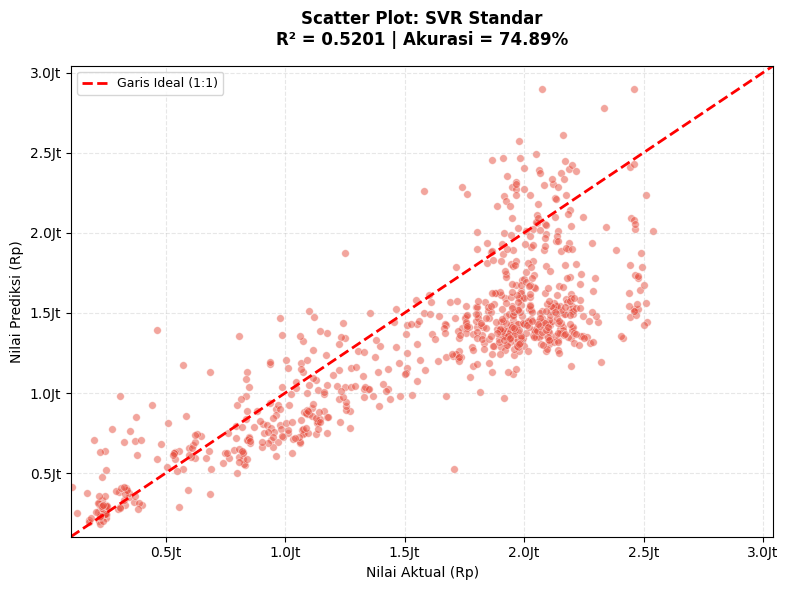

   ✅ Tersimpan: scatter_svr_standar.png


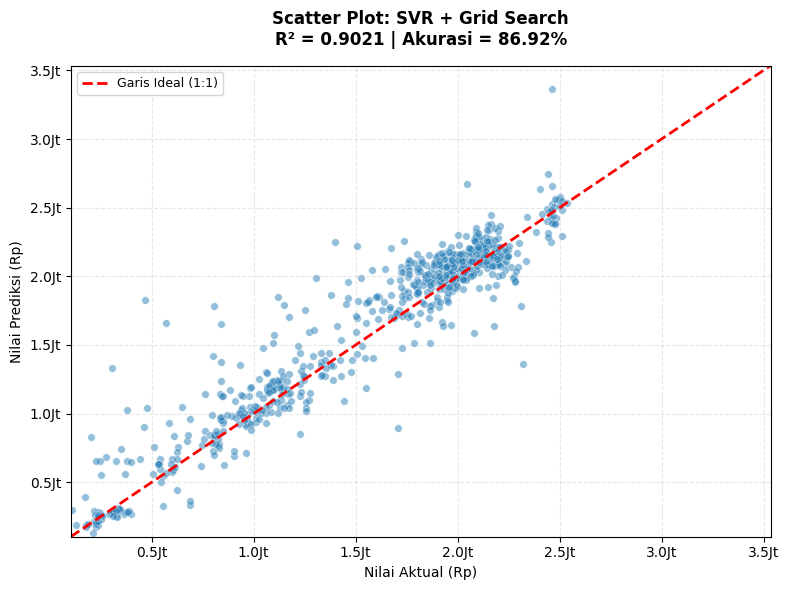

   ✅ Tersimpan: scatter_svr__grid_search.png


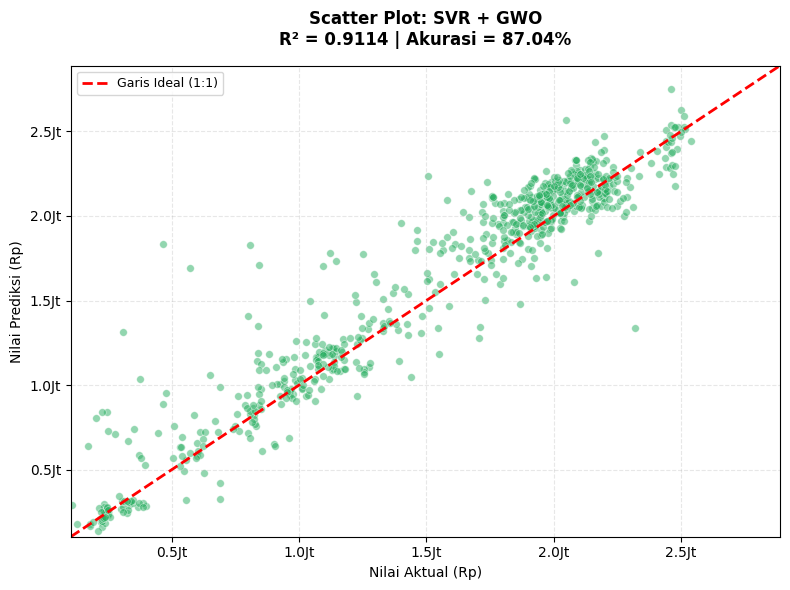

   ✅ Tersimpan: scatter_svr__gwo.png
✅ CELL 11 BERHASIL: Scatter Plot 3 Model selesai!


In [ ]:
# ============================================================
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 11 — SCATTER PLOT AKTUAL VS PREDIKSI (3 MODEL)    ║
# ╚══════════════════════════════════════════════════════════╝
# ============================================================

from sklearn.metrics import r2_score

scatter_data = [
    (y_pred_base_test, 'SVR Standar',      '#E74C3C'),
    (y_pred_gs_test,   'SVR + Grid Search', '#2980B9'),
    (y_pred_gwo_test,  'SVR + GWO',         '#27AE60'),
]

for y_pred, nama, warna in scatter_data:
    plt.figure(figsize=(8, 6))

    plt.scatter(y_test_asli, y_pred,
                color=warna, alpha=0.5, s=30,
                edgecolors='white', linewidth=0.5)

    semua = np.concatenate([y_test_asli, y_pred])
    lims  = [semua.min() * 0.95, semua.max() * 1.05]
    plt.plot(lims, lims, 'r--', lw=2, label='Garis Ideal (1:1)')

    r2_val  = r2_score(y_test_asli, y_pred)
    mape_v  = np.mean(np.abs((y_test_asli - y_pred) / y_test_asli)) * 100
    akurasi = max(0, 100 - mape_v)

    plt.title(f'Scatter Plot: {nama}\nR² = {r2_val:.4f} | Akurasi = {akurasi:.2f}%',
              fontweight='bold', fontsize=12, pad=15)
    plt.xlabel('Nilai Aktual (Rp)', fontsize=10)
    plt.ylabel('Nilai Prediksi (Rp)', fontsize=10)

    fmt = plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}Jt')
    plt.gca().xaxis.set_major_formatter(fmt)
    plt.gca().yaxis.set_major_formatter(fmt)

    plt.xlim(lims)
    plt.ylim(lims)
    plt.grid(True, ls='--', alpha=0.3)
    plt.legend(loc='upper left', fontsize=9)
    plt.tight_layout()

    filename = f"scatter_{nama.lower().replace('+', '').replace(' ', '_')}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"   ✅ Tersimpan: {filename}")

print("✅ CELL 11 BERHASIL: Scatter Plot 3 Model selesai!")

# GRAFIK PLOT AKTUAL VS PREDIKSI

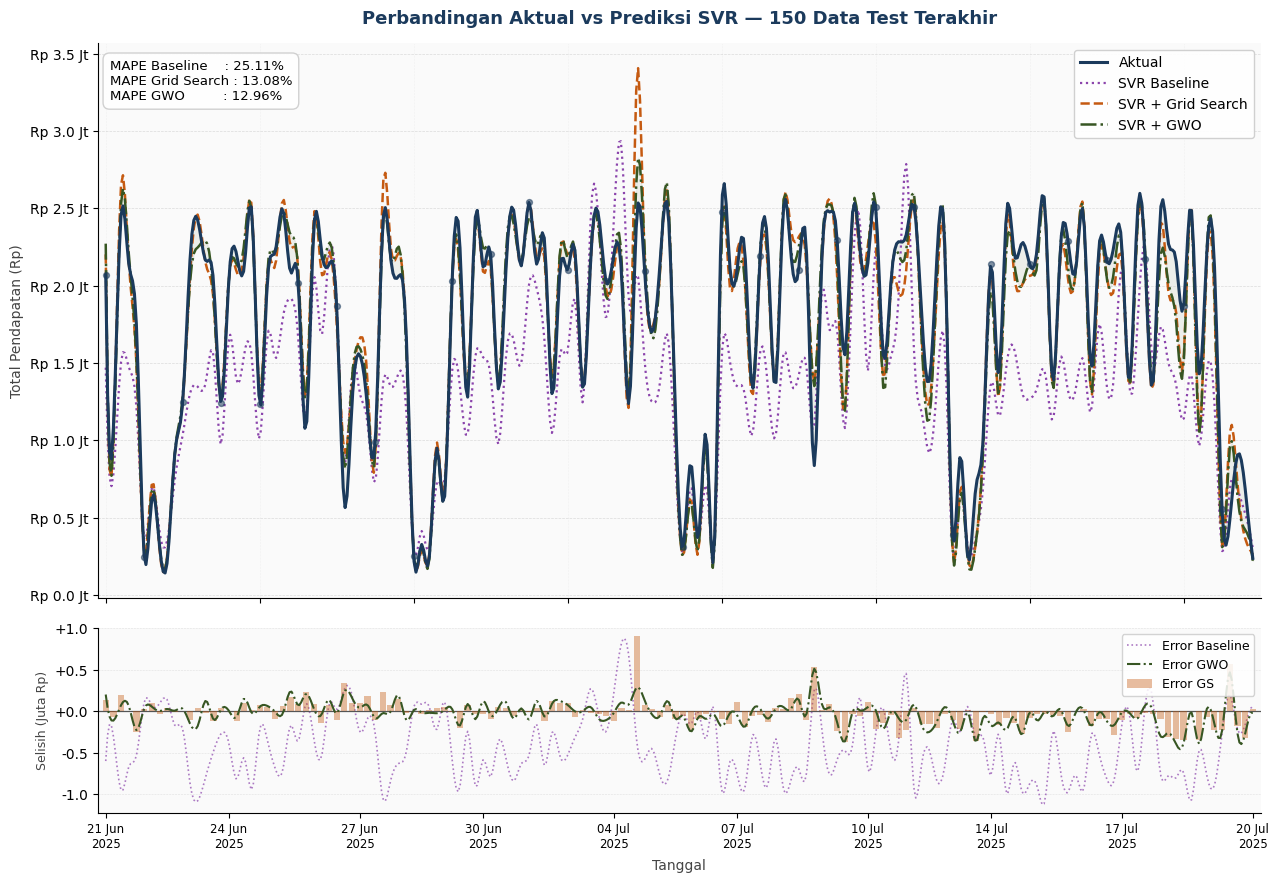

✅ Grafik berhasil disimpan.
   MAPE Baseline    : 25.1129%
   MAPE Grid Search : 13.0788%
   MAPE GWO         : 12.9644%
   Model terbaik    : SVR GWO


In [ ]:

# CELL UNTUK GRAFIK PLOT AKTUAL VS PREDIKSI

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import numpy as np
from scipy.interpolate import make_interp_spline

# ─── Cek semua variabel yang diperlukan ─────────────────────
required = ['y_test_asli', 'y_pred_base_test', 'y_pred_gs_test', 'y_pred_gwo_test']
missing  = [v for v in required if v not in globals()]

if missing:
    print("❌ ERROR: Variabel berikut tidak ditemukan:", missing)
    print("Pastikan Cell 7 (Baseline), Cell 8 (Grid Search), Cell 9 (GWO) sudah dijalankan.")
else:
    # ─── Data ───────────────────────────────────────────────
    n_zoom   = 150
    df_zoom  = df_test.tail(n_zoom).copy().reset_index(drop=True)
    y_act    = y_test_asli[-n_zoom:]
    y_base   = y_pred_base_test[-n_zoom:]       # ← SVR Baseline
    y_gs     = y_pred_gs_test[-n_zoom:]
    y_gwo    = y_pred_gwo_test[-n_zoom:]
    tanggal  = df_zoom['Tanggal'].values

    x        = np.arange(n_zoom)
    x_smooth = np.linspace(0, n_zoom - 1, 600)

    def smooth(y):
        spl = make_interp_spline(x, y, k=3)
        return spl(x_smooth)

    # ─── Style ──────────────────────────────────────────────
    plt.rcParams.update({
        'font.family'      : 'DejaVu Sans',
        'axes.spines.top'  : False,
        'axes.spines.right': False,
    })

    fig, axes = plt.subplots(
        2, 1,
        figsize=(15, 10),
        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08},
        sharex=False
    )

    # ── Warna ──
    COL_ACT  = '#1B3A5C'   # navy  — Aktual
    COL_BASE = '#8B44AC'   # ungu  — SVR Baseline
    COL_GS   = '#C55A11'   # oranye tua — Grid Search
    COL_GWO  = '#375623'   # hijau tua  — GWO

    # ════════════════════════════════
    # PANEL ATAS — Aktual vs Prediksi
    # ════════════════════════════════
    ax = axes[0]
    ax.set_facecolor('#FAFAFA')
    fig.patch.set_facecolor('white')

    # Shaded area perbedaan GWO vs Aktual
    ax.fill_between(x_smooth, smooth(y_act), smooth(y_gwo),
                    alpha=0.07, color=COL_GWO, label='_nolegend_')

    # Garis aktual
    ax.plot(x_smooth, smooth(y_act),
            color=COL_ACT, linewidth=2.2, label='Aktual', zorder=5)

    # Scatter titik aktual (sparse agar tidak ramai)
    ax.scatter(x[::5], y_act[::5],
               color=COL_ACT, s=18, zorder=6, alpha=0.55)

    # Garis prediksi SVR Baseline ← BARU
    ax.plot(x_smooth, smooth(y_base),
            color=COL_BASE, linewidth=1.6, linestyle=':',
            label='SVR Baseline', zorder=2)

    # Garis prediksi Grid Search
    ax.plot(x_smooth, smooth(y_gs),
            color=COL_GS, linewidth=1.8, linestyle='--',
            label='SVR + Grid Search', zorder=3)

    # Garis prediksi GWO
    ax.plot(x_smooth, smooth(y_gwo),
            color=COL_GWO, linewidth=1.8, linestyle='-.',
            label='SVR + GWO', zorder=3)

    # Annotasi MAPE — sekarang 3 baris
    ax.text(0.01, 0.97,
            f"MAPE Baseline    : {mape_base_test:.2f}%\n"
            f"MAPE Grid Search : {mape_gs_test:.2f}%\n"
            f"MAPE GWO         : {mape_gwo_test:.2f}%",
            transform=ax.transAxes, fontsize=9.5,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      edgecolor='#CCCCCC', alpha=0.9))

    ax.set_title(
        f'Perbandingan Aktual vs Prediksi SVR — {n_zoom} Data Test Terakhir',
        fontsize=13, fontweight='bold', pad=14, color='#1B3A5C'
    )
    ax.set_ylabel('Total Pendapatan (Rp)', fontsize=10, color='#444444')
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f'Rp {v/1e6:.1f} Jt'))
    ax.legend(loc='upper right', frameon=True, framealpha=0.9,
              edgecolor='#CCCCCC', fontsize=10)
    ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5, color='#BBBBBB')
    ax.grid(axis='x', linestyle=':', linewidth=0.4, alpha=0.3, color='#BBBBBB')
    ax.tick_params(labelbottom=False)

    # ════════════════════════════════
    # PANEL BAWAH — Selisih (Error)
    # ════════════════════════════════
    ax2 = axes[1]
    ax2.set_facecolor('#FAFAFA')

    err_base = y_base - y_act      # ← BARU
    err_gs   = y_gs   - y_act
    err_gwo  = y_gwo  - y_act

    # Garis error Baseline ← BARU (dotted tipis di bawah semua)
    ax2.plot(x_smooth, smooth(err_base) / 1e6,
             color=COL_BASE, linewidth=1.2, linestyle=':',
             alpha=0.7, label='Error Baseline', zorder=2)

    # Bar error GS
    ax2.bar(x, err_gs / 1e6,
            color=COL_GS, alpha=0.40, width=0.8, label='Error GS', zorder=3)

    # Garis error GWO
    ax2.plot(x_smooth, smooth(err_gwo) / 1e6,
             color=COL_GWO, linewidth=1.5, linestyle='-.', label='Error GWO', zorder=4)

    ax2.axhline(0, color='#555555', linewidth=0.9, linestyle='-')
    ax2.set_ylabel('Selisih (Juta Rp)', fontsize=9, color='#444444')
    ax2.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f'{v:+.1f}'))
    ax2.legend(loc='upper right', frameon=True, framealpha=0.85,
               edgecolor='#CCCCCC', fontsize=9)
    ax2.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.4, color='#BBBBBB')

    # X-tick tanggal — tampilkan 10 label merata
    tick_idx = np.linspace(0, n_zoom - 1, 10, dtype=int)
    ax2.set_xticks(tick_idx)
    ax2.set_xticklabels(
        df_zoom['Tanggal'].iloc[tick_idx].dt.strftime('%d %b\n%Y'),
        fontsize=8.5, rotation=0, ha='center'
    )
    ax2.set_xlabel('Tanggal', fontsize=10, color='#444444', labelpad=6)
    ax2.set_xlim(-1, n_zoom)

    # Selaraskan xlim panel atas
    axes[0].set_xlim(-1, n_zoom)

    # ─── Simpan ─────────────────────────────────────────────
    plt.savefig('plot_aktual_vs_prediksi_smooth.png',
                dpi=160, bbox_inches='tight', facecolor='white')
    plt.show()

    # ─── Rangkuman ──────────────────────────────────────────
    models = {
        'SVR Baseline'  : mape_base_test,
        'SVR Grid Search': mape_gs_test,
        'SVR GWO'       : mape_gwo_test,
    }
    best = min(models, key=models.get)

    print(f"✅ Grafik berhasil disimpan.")
    print(f"   MAPE Baseline    : {mape_base_test:.4f}%")
    print(f"   MAPE Grid Search : {mape_gs_test:.4f}%")
    print(f"   MAPE GWO         : {mape_gwo_test:.4f}%")
    print(f"   Model terbaik    : {best}")

# EVALUASI METRIK & AKURASI MODEL

In [ ]:
# ============================================================
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 12 — EVALUASI AKHIR & AKURASI MODEL               ║
# ╚══════════════════════════════════════════════════════════╝
# ============================================================

print("\n" + "=" * 72)
print("  📊  RINGKASAN EVALUASI AKHIR — 3 MODEL SVR")
print("=" * 72)

def buat_baris(nama, mae, rmse, mape_test, mape_train, r2, waktu):
    gap     = abs(mape_test - mape_train)
    akurasi = max(0, 100 - mape_test)
    status  = "✅ Baik" if gap < 5 else ("⚠️ Perlu Cek" if gap < 10 else "❌ Overfit")
    return {
        'Model'       : nama,
        'MAE (Rp)'    : f"Rp {mae:,.0f}",
        'RMSE (Rp)'   : f"Rp {rmse:,.0f}",
        'MAPE Test'   : f"{mape_test:.4f}%",
        'MAPE Train'  : f"{mape_train:.4f}%",
        'Gap Overfit' : f"{gap:.4f}%",
        'R²'          : f"{r2:.6f}",
        'Akurasi'     : f"{akurasi:.2f}%",
        'Status'      : status,
        'Waktu'       : f"{waktu:.1f}s",
    }

df_eval = pd.DataFrame([
    buat_baris("SVR Baseline",      mae_base, rmse_base,
               mape_base_test, mape_base_train, r2_base, lama_base),
    buat_baris("SVR + Grid Search", mae_gs,   rmse_gs,
               mape_gs_test,   mape_gs_train,   r2_gs,   lama_gs),
    buat_baris("SVR + GWO",         mae_gwo,  rmse_gwo,
               mape_gwo_test,  mape_gwo_train,  r2_gwo,  lama_gwo),
])

display(df_eval.style
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        {'selector': 'th',
         'props': [('background-color','#2C3E50'),('color','white'),
                   ('font-weight','bold'),('text-align','center')]},
        {'selector': 'tr:nth-child(4)',
         'props': [('background-color','#EAFAF1'),('font-weight','bold')]}
    ])
)

mapes         = {'SVR Baseline'    : mape_base_test,
                 'SVR + Grid Search': mape_gs_test,
                 'SVR + GWO'       : mape_gwo_test}
model_terbaik = min(mapes, key=mapes.get)
akurasi_terbaik = max(0, 100 - mapes[model_terbaik])

print("\n" + "─" * 72)
print(f"  🏆  MODEL TERBAIK : {model_terbaik}")
print(f"  📉  MAPE Test     : {mapes[model_terbaik]:.4f}%")
print(f"  🎯  AKURASI       : {akurasi_terbaik:.2f}%")
print(f"  📈  R²            : {r2_gwo:.6f}")
print("─" * 72)
print("\n💡 Catatan Metrik:")
print("   MAE, RMSE, MAPE → Semakin KECIL  = semakin BAGUS")
print("   R²              → Semakin BESAR  = semakin BAGUS (maks 1.0)")
print("   Gap Overfit     → <5% AMAN | 5-10% PERLU CEK | >10% OVERFIT")
print("   Akurasi         → 100% − MAPE (konvensi skripsi)")
print("\n✅ CELL 12 SELESAI!")


  📊  RINGKASAN EVALUASI AKHIR — 3 MODEL SVR


,Model,MAE (Rp),RMSE (Rp),MAPE Test,MAPE Train,Gap Overfit,R²,Akurasi,Status,Waktu
0,SVR Baseline,"Rp 369,655","Rp 451,420",25.1129%,22.6831%,2.4298%,0.520081,74.89%,✅ Baik,0.2s
1,SVR + Grid Search,"Rp 135,957","Rp 203,896",13.0788%,7.2972%,5.7816%,0.902091,86.92%,⚠️ Perlu Cek,1778.0s
2,SVR + GWO,"Rp 130,623","Rp 194,009",12.9644%,9.3622%,3.6022%,0.911356,87.04%,✅ Baik,4293.8s



────────────────────────────────────────────────────────────────────────
  🏆  MODEL TERBAIK : SVR + GWO
  📉  MAPE Test     : 12.9644%
  🎯  AKURASI       : 87.04%
  📈  R²            : 0.911356
────────────────────────────────────────────────────────────────────────

💡 Catatan Metrik:
   MAE, RMSE, MAPE → Semakin KECIL  = semakin BAGUS
   R²              → Semakin BESAR  = semakin BAGUS (maks 1.0)
   Gap Overfit     → <5% AMAN | 5-10% PERLU CEK | >10% OVERFIT
   Akurasi         → 100% − MAPE (konvensi skripsi)

✅ CELL 12 SELESAI!


# MODEL CHECKPOINT

In [ ]:
# ============================================================
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 12B — SMART MODEL CHECKPOINT (3 MODEL)            ║
# ║  Simpan tiap model secara independen                    ║
# ║  Otomatis pakai model lama jika run baru lebih jelek    ║
# ╚══════════════════════════════════════════════════════════╝
# ============================================================

import pickle, json, os
from datetime import datetime

CKPT_DIR = "/content/drive/MyDrive/SKRIPSI/MODEL_CHECKPOINT"
os.makedirs(CKPT_DIR, exist_ok=True)

def save_checkpoint(name, model, mape_test, mae, rmse, r2):
    key    = name.lower().replace(" ","_").replace("+","").replace("svr","svr").strip("_")
    f_pkl  = f"{CKPT_DIR}/{key}.pkl"
    f_json = f"{CKPT_DIR}/{key}_info.json"

    # ── Cek checkpoint lama ──
    prev_mape = None
    if os.path.exists(f_json):
        with open(f_json) as f:
            prev = json.load(f)
        prev_mape = prev['mape_test']
        print(f"   📂 Checkpoint lama : MAPE={prev_mape:.4f}% | {prev['saved_at']}")

    if prev_mape is None or mape_test < prev_mape:
        # ── Simpan ──
        with open(f_pkl, 'wb') as f:
            pickle.dump({
                'model': model, 'scaler_X': scaler_X, 'scaler_y': scaler_y,
                'fitur': fitur, 'model_name': name,
                'mape_test': mape_test, 'mae_test': mae,
                'rmse_test': rmse, 'r2_test': r2,
            }, f)
        with open(f_json, 'w') as f:
            json.dump({
                'model_name': name, 'mape_test': mape_test,
                'mae_test': mae, 'rmse_test': rmse, 'r2_test': r2,
                'akurasi': max(0, 100-mape_test),
                'n_fitur': len(fitur), 'n_train': len(df_train),
                'n_test': len(df_test),
                'saved_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
                'params': {'C': float(model.C), 'epsilon': float(model.epsilon),
                           'gamma': str(model.gamma)}
            }, f, indent=2)
        if prev_mape is None:
            print(f"   ✅ Pertama kali disimpan → MAPE={mape_test:.4f}%")
        else:
            print(f"   ✅ LEBIH BAIK! {prev_mape:.4f}% → {mape_test:.4f}% (↓{prev_mape-mape_test:.4f}%)")
        return model  # pakai model baru
    else:
        print(f"   ⏭️  Tidak update. Lama={prev_mape:.4f}% ≤ Baru={mape_test:.4f}%")
        # ── Load model lama ──
        with open(f_pkl, 'rb') as f:
            ckpt = pickle.load(f)
        print(f"   🔄 Memakai model lama dari checkpoint")
        return ckpt['model']  # kembalikan model lama

print("=" * 62)
print("  💾  SMART MODEL CHECKPOINT — 3 MODEL")
print("=" * 62)

# ── Baseline ──
print(f"\n  [1/3] SVR Baseline  (MAPE Test: {mape_base_test:.4f}%)")
svr_baseline_final = save_checkpoint(
    "SVR_Baseline", svr_baseline,
    mape_base_test, mae_base, rmse_base, r2_base)

# ── Grid Search ──
print(f"\n  [2/3] SVR Grid Search (MAPE Test: {mape_gs_test:.4f}%)")
svr_gs_final = save_checkpoint(
    "SVR_Grid_Search", svr_gs,
    mape_gs_test, mae_gs, rmse_gs, r2_gs)

# ── GWO ──
print(f"\n  [3/3] SVR GWO  (MAPE Test: {mape_gwo_test:.4f}%)")
svr_gwo_final = save_checkpoint(
    "SVR_GWO", svr_gwo,
    mape_gwo_test, mae_gwo, rmse_gwo, r2_gwo)

print(f"\n{'='*62}")

# ── Update prediksi pakai model final (mungkin dari checkpoint) ──
print("  🔄 Update prediksi menggunakan model final terbaik...")
y_pred_base_train  = inverse_pred(svr_baseline_final.predict(X_train))
y_pred_base_test   = inverse_pred(svr_baseline_final.predict(X_test))
y_pred_gs_train    = inverse_pred(svr_gs_final.predict(X_train))
y_pred_gs_test     = inverse_pred(svr_gs_final.predict(X_test))
y_pred_gwo_train   = inverse_pred(svr_gwo_final.predict(X_train))
y_pred_gwo_test    = inverse_pred(svr_gwo_final.predict(X_test))

# ── Update metrik ──
mae_base,  rmse_base,  mape_base_test,  r2_base  = hitung_metrik(y_test_asli,  y_pred_base_test)
_,         _,          mape_base_train, _         = hitung_metrik(y_train_asli, y_pred_base_train)
mae_gs,    rmse_gs,    mape_gs_test,    r2_gs     = hitung_metrik(y_test_asli,  y_pred_gs_test)
_,         _,          mape_gs_train,   _         = hitung_metrik(y_train_asli, y_pred_gs_train)
mae_gwo,   rmse_gwo,   mape_gwo_test,   r2_gwo    = hitung_metrik(y_test_asli,  y_pred_gwo_test)
_,         _,          mape_gwo_train,  _         = hitung_metrik(y_train_asli, y_pred_gwo_train)

# ── Juga update variabel model ──
svr_baseline = svr_baseline_final
svr_gs       = svr_gs_final
svr_gwo      = svr_gwo_final

print("  ✅ Prediksi & metrik diupdate dari model final terbaik")
print(f"\n  📊 Metrik Final (dari model terbaik masing-masing):")
print(f"  {'Model':<20} {'MAPE Test':>10} {'Akurasi':>10} {'R²':>10}")
print(f"  {'-'*52}")
for nm, mape, r2_ in [
    ("SVR Baseline",     mape_base_test, r2_base),
    ("SVR Grid Search",  mape_gs_test,   r2_gs),
    ("SVR GWO",          mape_gwo_test,  r2_gwo),
]:
    print(f"  {nm:<20} {mape:>9.4f}% {max(0,100-mape):>9.2f}% {r2_:>10.6f}")

print(f"\n  📁 Semua checkpoint tersimpan di:")
print(f"     {CKPT_DIR}/")
print("=" * 62)
print("✅ CELL 12B SELESAI!")

  💾  SMART MODEL CHECKPOINT — 3 MODEL

  [1/3] SVR Baseline  (MAPE Test: 25.1129%)
   📂 Checkpoint lama : MAPE=25.1129% | 2026-04-29 14:42:50
   ⏭️  Tidak update. Lama=25.1129% ≤ Baru=25.1129%
   🔄 Memakai model lama dari checkpoint

  [2/3] SVR Grid Search (MAPE Test: 13.0788%)
   📂 Checkpoint lama : MAPE=13.0788% | 2026-04-29 14:42:50
   ⏭️  Tidak update. Lama=13.0788% ≤ Baru=13.0788%
   🔄 Memakai model lama dari checkpoint

  [3/3] SVR GWO  (MAPE Test: 12.9644%)
   📂 Checkpoint lama : MAPE=12.9644% | 2026-05-11 05:01:45
   ⏭️  Tidak update. Lama=12.9644% ≤ Baru=12.9644%
   🔄 Memakai model lama dari checkpoint

  🔄 Update prediksi menggunakan model final terbaik...
  ✅ Prediksi & metrik diupdate dari model final terbaik

  📊 Metrik Final (dari model terbaik masing-masing):
  Model                 MAPE Test    Akurasi         R²
  ----------------------------------------------------
  SVR Baseline           25.1129%     74.89%   0.520081
  SVR Grid Search        13.0788%     86.92%   

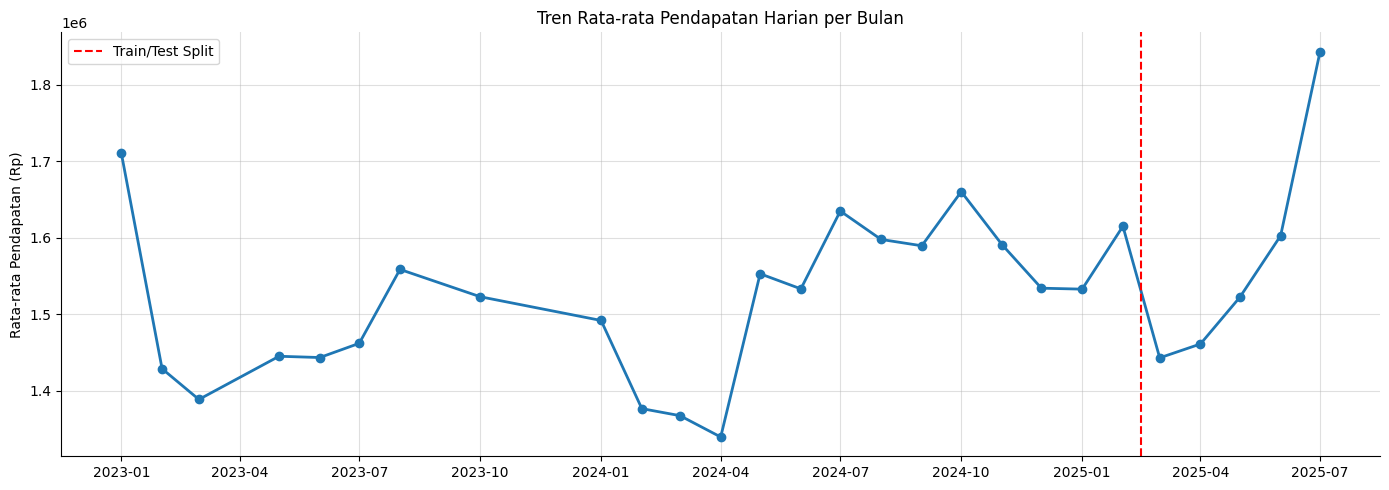

Rata-rata pendapatan per tahun:
              mean      std      min        max
Tanggal                                        
2023     1,466,025  554,994   42,000  2,049,000
2024     1,527,904  617,653   40,000  2,190,000
2025     1,560,395  644,957  109,000  2,538,000


In [ ]:
import matplotlib.pyplot as plt

# Plot tren bulanan
df_monthly = df_sorted.groupby(
    df_sorted['Tanggal'].dt.to_period('M')
)['Total_Pendapatan'].mean().reset_index()
df_monthly['Tanggal'] = df_monthly['Tanggal'].dt.to_timestamp()

plt.figure(figsize=(14, 5))
plt.plot(df_monthly['Tanggal'], df_monthly['Total_Pendapatan'],
         marker='o', linewidth=2)
plt.axvline(df_sorted.iloc[split_idx]['Tanggal'],
            color='red', linestyle='--', label='Train/Test Split')
plt.title('Tren Rata-rata Pendapatan Harian per Bulan')
plt.ylabel('Rata-rata Pendapatan (Rp)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Statistik per tahun
print("Rata-rata pendapatan per tahun:")
print(df_sorted.groupby(df_sorted['Tanggal'].dt.year)['Total_Pendapatan'].agg(['mean','std','min','max']).apply(lambda x: x.map('{:,.0f}'.format)))

# EXPORT EXCEL

In [ ]:
# ============================================================
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 14 REVISI — EXPORT EXCEL 11 SHEET                 ║
# ║  PERUBAHAN dari versi sebelumnya:                        ║
# ║  1. Data Mentah     → SEMUA baris (bukan 1000)           ║
# ║  2. Feature Eng.    → SEMUA baris (bukan 300)            ║
# ║  3. Sheet baru      → Data Cleaning (tabel detail)       ║
# ║  4. Model           → Diload dari Drive checkpoint       ║
# ╚══════════════════════════════════════════════════════════╝
# CARA PAKAI:
#   Jalankan CELL 1–5 dulu (load data, feature engineering, split),
#   lalu jalankan cell ini. Model SVR, GS, GWO akan diload
#   otomatis dari Google Drive checkpoint.
# ============================================================

import os, pickle, json, openpyxl, numpy as np, pandas as pd
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.chart import LineChart, Reference
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ─────────────────────────────────────────────────────────────
# 0. LOAD MODEL DARI CHECKPOINT GOOGLE DRIVE
# ─────────────────────────────────────────────────────────────
CKPT_DIR = "/content/drive/MyDrive/SKRIPSI/MODEL_CHECKPOINT"

def load_checkpoint(key):
    f_pkl  = f"{CKPT_DIR}/{key}.pkl"
    f_json = f"{CKPT_DIR}/{key}_info.json"
    if not os.path.exists(f_pkl):
        raise FileNotFoundError(f"❌ Checkpoint tidak ditemukan: {f_pkl}")
    with open(f_pkl, 'rb') as f:
        ckpt = pickle.load(f)
    with open(f_json) as f:
        info = json.load(f)
    print(f"   ✅ [{key}] loaded — MAPE={info['mape_test']:.4f}% | saved={info['saved_at']}")
    return ckpt, info

print("=" * 60)
print("  📦  LOAD MODEL DARI GOOGLE DRIVE CHECKPOINT")
print("=" * 60)

ckpt_base, info_base = load_checkpoint("svr_baseline")
ckpt_gs,   info_gs   = load_checkpoint("svr_grid_search")
ckpt_gwo,  info_gwo  = load_checkpoint("svr_gwo")

# Ambil model & scaler dari checkpoint
svr_baseline = ckpt_base['model']
svr_gs       = ckpt_gs['model']
svr_gwo      = ckpt_gwo['model']
scaler_X_ckpt = ckpt_gwo['scaler_X']   # semua pakai scaler yang sama
scaler_y_ckpt = ckpt_gwo['scaler_y']
fitur_ckpt    = ckpt_gwo['fitur']

# Gunakan scaler & fitur dari checkpoint (lebih aman)
# Jika variabel global scaler_X, scaler_y, fitur sudah ada dari cell sebelumnya,
# checkpoint akan dipakai sebagai validasi.
try:
    _ = scaler_X  # cek apakah sudah ada dari cell sebelumnya
    print("   ℹ️  scaler_X dari cell sebelumnya tersedia — tetap pakai checkpoint untuk konsistensi")
except NameError:
    scaler_X = scaler_X_ckpt
    scaler_y = scaler_y_ckpt
    fitur    = fitur_ckpt
    print("   ℹ️  scaler & fitur diambil dari checkpoint")

# ─────────────────────────────────────────────────────────────
# HELPER: inverse transform
# ─────────────────────────────────────────────────────────────
def inverse_pred(y_scaled):
    y_log = scaler_y.inverse_transform(y_scaled.reshape(-1, 1)).flatten()
    return np.expm1(y_log)

def hitung_metrik(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true > 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, mape, r2

# ─────────────────────────────────────────────────────────────
# Pastikan df_train, df_test, X_train, X_test tersedia
# ─────────────────────────────────────────────────────────────
print("\n  🔄 Menghitung prediksi dari model checkpoint...")
X_tr = scaler_X.transform(df_train[fitur].values)
X_te = scaler_X.transform(df_test[fitur].values)

y_pred_base_train  = inverse_pred(svr_baseline.predict(X_tr))
y_pred_base_test   = inverse_pred(svr_baseline.predict(X_te))
y_pred_gs_train    = inverse_pred(svr_gs.predict(X_tr))
y_pred_gs_test     = inverse_pred(svr_gs.predict(X_te))
y_pred_gwo_train   = inverse_pred(svr_gwo.predict(X_tr))
y_pred_gwo_test    = inverse_pred(svr_gwo.predict(X_te))

y_train_asli = df_train['Total_Pendapatan'].values
y_test_asli  = df_test['Total_Pendapatan'].values

mae_base, rmse_base, mape_base_test,  r2_base  = hitung_metrik(y_test_asli,  y_pred_base_test)
_,        _,         mape_base_train, _         = hitung_metrik(y_train_asli, y_pred_base_train)
mae_gs,   rmse_gs,   mape_gs_test,    r2_gs     = hitung_metrik(y_test_asli,  y_pred_gs_test)
_,        _,         mape_gs_train,   _         = hitung_metrik(y_train_asli, y_pred_gs_train)
mae_gwo,  rmse_gwo,  mape_gwo_test,   r2_gwo    = hitung_metrik(y_test_asli,  y_pred_gwo_test)
_,        _,         mape_gwo_train,  _         = hitung_metrik(y_train_asli, y_pred_gwo_train)
mae_base_tr,  rmse_base_tr,  mape_base_tr,  r2_base_tr  = hitung_metrik(y_train_asli, y_pred_base_train)
mae_gs_tr,    rmse_gs_tr,    mape_gs_tr,    r2_gs_tr    = hitung_metrik(y_train_asli, y_pred_gs_train)
mae_gwo_tr,   rmse_gwo_tr,   mape_gwo_tr,   r2_gwo_tr   = hitung_metrik(y_train_asli, y_pred_gwo_train)

lama_base = info_base.get('waktu', 0)
lama_gs   = info_gs.get('waktu', 0)
lama_gwo  = info_gwo.get('waktu', 0)
best_params  = info_gs.get('params', {})
BEST_C       = info_gwo['params']['C']
BEST_EPS     = info_gwo['params']['epsilon']
BEST_GAMMA   = info_gwo['params']['gamma']

print("  ✅ Prediksi selesai")
print(f"\n  Model          MAPE Test   Akurasi      R²")
print(f"  {'─'*50}")
for nm, mt, r2_ in [("SVR Baseline",  mape_base_test, r2_base),
                    ("SVR Grid Search",mape_gs_test,   r2_gs),
                    ("SVR GWO",        mape_gwo_test,  r2_gwo)]:
    print(f"  {nm:<16} {mt:>8.4f}%  {max(0,100-mt):>8.2f}%  {r2_:>10.6f}")

# ─────────────────────────────────────────────────────────────
# DATA CLEANING — rekonstruksi tabel sebelum vs sesudah
# ─────────────────────────────────────────────────────────────
# Reload data mentah asli untuk tabel cleaning
file_path = '/content/drive/MyDrive/SKRIPSI/DATA_PARKIR/DATA_PENDAPATAN_PARKIR_PER_HARI_2023-2025.csv'
df_raw = pd.read_csv(file_path, parse_dates=['Tanggal'])
n_raw_total  = len(df_raw)
n_zero_total = (df_raw['Total_Pendapatan'] == 0).sum()

libur_nasional_id = pd.to_datetime([
    '2023-01-01','2023-01-22','2023-02-18','2023-03-22',
    '2023-04-07','2023-04-21','2023-04-22','2023-05-01',
    '2023-05-18','2023-05-24','2023-06-01','2023-06-28',
    '2023-07-19','2023-08-17','2023-09-27','2023-12-25',
    '2024-01-01','2024-02-08','2024-02-14','2024-03-11',
    '2024-03-29','2024-04-10','2024-04-11','2024-05-01',
    '2024-05-09','2024-05-23','2024-06-01','2024-06-17',
    '2024-07-07','2024-08-17','2024-09-16','2024-12-25',
    '2025-01-01','2025-01-27','2025-01-29','2025-03-29',
    '2025-03-31','2025-04-01','2025-04-18','2025-05-01',
    '2025-05-12','2025-05-29','2025-06-01','2025-06-06',
    '2025-06-27','2025-08-17','2025-09-05','2025-12-25',
])
df_raw['Libur_Nasional_flag'] = df_raw['Tanggal'].dt.normalize().isin(libur_nasional_id).astype(int)

# Baris zero yang BUKAN hari libur → dihapus
mask_hapus   = (df_raw['Total_Pendapatan'] == 0) & (df_raw['Libur_Nasional_flag'] != 1)
df_raw_clean = df_raw[~mask_hapus].copy().reset_index(drop=True)
n_zero_libur = int(((df_raw['Total_Pendapatan'] == 0) & (df_raw['Libur_Nasional_flag'] == 1)).sum())
n_hapus      = int(mask_hapus.sum())

# Imputasi zero pada hari libur
median_libur = float(df_raw_clean[(df_raw_clean['Libur_Nasional_flag'] == 1) &
                                   (df_raw_clean['Total_Pendapatan'] > 0)]['Total_Pendapatan'].median())
n_imputasi   = int(((df_raw_clean['Libur_Nasional_flag'] == 1) &
                    (df_raw_clean['Total_Pendapatan'] == 0)).sum())
df_raw_clean.loc[(df_raw_clean['Libur_Nasional_flag'] == 1) &
                  (df_raw_clean['Total_Pendapatan'] == 0), 'Total_Pendapatan'] = median_libur

n_after_clean = len(df_raw_clean)
n_duplikat    = int(df_raw.duplicated().sum())
n_missing     = int(df_raw['Total_Pendapatan'].isna().sum())

# Detail baris yang dihapus (maks 50 untuk tabel)
df_hapus_detail = df_raw[mask_hapus][['Tanggal','Hari','Rayon','Total_Pendapatan','Libur_Nasional_flag']].head(50)

print(f"\n  🧹 Data Cleaning:")
print(f"     Baris raw    : {n_raw_total:,}")
print(f"     Zero total   : {n_zero_total}")
print(f"     Zero non-libur dihapus : {n_hapus}")
print(f"     Zero libur diimputasi  : {n_imputasi} → median Rp {median_libur:,.0f}")
print(f"     Baris setelah cleaning : {n_after_clean:,}")
print(f"     Duplikat     : {n_duplikat}")
print(f"     Missing value: {n_missing}")

# ─────────────────────────────────────────────────────────────
# SETUP EXCEL
# ─────────────────────────────────────────────────────────────
os.makedirs("/content/drive/MyDrive/SKRIPSI/EXCEL_MODEL", exist_ok=True)

C_H1 = "1B3A5C"; C_H2 = "2C5282"; C_H3 = "BDD7EE"; C_H3FG = "1B3A5C"
C_W  = "FFFFFF"; C_G1 = "F2F2F2"; C_HGL = "FFF2CC"
C_POS = "375623"; C_NEG = "C00000"; C_BDR = "000000"

day_names = ["Senin","Selasa","Rabu","Kamis","Jumat","Sabtu","Minggu"]

LIBUR_NAMES = {
    "2023-01-01":"Tahun Baru Masehi 2023","2023-01-22":"Tahun Baru Imlek 2574",
    "2023-02-18":"Isra Mi'raj 2023","2023-03-22":"Hari Raya Nyepi",
    "2023-04-07":"Wafat Isa Al-Masih","2023-04-21":"Idul Fitri 1444 H",
    "2023-04-22":"Idul Fitri 1444 H (Hari 2)","2023-05-01":"Hari Buruh",
    "2023-05-18":"Kenaikan Isa Al-Masih","2023-05-24":"Hari Raya Waisak",
    "2023-06-01":"Hari Lahir Pancasila","2023-06-28":"Idul Adha 1444 H",
    "2023-07-19":"Tahun Baru Islam 1445 H","2023-08-17":"HUT RI ke-78",
    "2023-09-27":"Maulid Nabi 2023","2023-12-25":"Hari Raya Natal",
    "2024-01-01":"Tahun Baru Masehi 2024","2024-02-08":"Tahun Baru Imlek 2575",
    "2024-02-14":"Isra Mi'raj 2024","2024-03-11":"Hari Raya Nyepi",
    "2024-03-29":"Wafat Isa Al-Masih","2024-04-10":"Idul Fitri 1445 H",
    "2024-04-11":"Idul Fitri 1445 H (Hari 2)","2024-05-01":"Hari Buruh",
    "2024-05-09":"Kenaikan Isa Al-Masih","2024-05-23":"Hari Raya Waisak",
    "2024-06-01":"Hari Lahir Pancasila","2024-06-17":"Idul Adha 1445 H",
    "2024-07-07":"Tahun Baru Islam 1446 H","2024-08-17":"HUT RI ke-79",
    "2024-09-16":"Maulid Nabi 2024","2024-12-25":"Hari Raya Natal",
    "2025-01-01":"Tahun Baru Masehi 2025","2025-01-27":"Isra Mi'raj 2025",
    "2025-01-29":"Tahun Baru Imlek 2576","2025-03-29":"Hari Raya Nyepi",
    "2025-03-31":"Idul Fitri 1446 H","2025-04-01":"Idul Fitri 1446 H (Hari 2)",
    "2025-04-18":"Wafat Isa Al-Masih","2025-05-01":"Hari Buruh",
    "2025-05-12":"Hari Raya Waisak","2025-05-29":"Kenaikan Isa Al-Masih",
    "2025-06-01":"Hari Lahir Pancasila","2025-06-06":"Idul Adha 1446 H",
    "2025-06-27":"Tahun Baru Islam 1447 H","2025-08-17":"HUT RI ke-80",
    "2025-09-05":"Maulid Nabi 2025","2025-12-25":"Hari Raya Natal",
}

def _bdr():
    s = Side(style="thin", color=C_BDR)
    return Border(left=s, right=s, top=s, bottom=s)

def _hdr(cell, text, bg=C_H3, fg=C_H3FG, sz=9, bold=True, wrap=False):
    cell.value = text
    cell.font  = Font(name="Arial", bold=bold, color=fg, size=sz)
    cell.fill  = PatternFill("solid", start_color=bg)
    cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=wrap)
    cell.border = _bdr()

def _val(cell, val, fg="000000", bg=None, bold=False, sz=9, align="center", fmt=None):
    cell.value = val
    cell.font  = Font(name="Arial", bold=bold, color=fg, size=sz)
    cell.alignment = Alignment(horizontal=align, vertical="center")
    cell.border = _bdr()
    if bg:  cell.fill = PatternFill("solid", start_color=bg)
    if fmt: cell.number_format = fmt

def _merge(ws, rng, text, bg=C_H1, fg=C_W, sz=10):
    ws.merge_cells(rng)
    c = ws[rng.split(":")[0]]
    c.value = text
    c.font  = Font(name="Arial", bold=True, color=fg, size=sz)
    c.fill  = PatternFill("solid", start_color=bg)
    c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    c.border = _bdr()

def _cw(ws, mapping):
    for col, w in mapping.items():
        ws.column_dimensions[col].width = w

def _alt(i): return C_G1 if i % 2 == 0 else C_W
def _col(n): return get_column_letter(n)

# ─────────────────────────────────────────────────────────────
df_sorted  = df.sort_values(['Tanggal','Rayon_asli']).reset_index(drop=True)
split_idx  = len(df_train)
rayon_list = sorted(df_sorted['Rayon_asli'].unique())

results = {
    "default":    dict(mae=mae_base,  rmse=rmse_base,  mape_test=mape_base_test,
                       mape_train=mape_base_train, r2=r2_base, waktu=lama_base,
                       params=dict(C=svr_baseline.C, epsilon=svr_baseline.epsilon, gamma=svr_baseline.gamma),
                       y_pred_train=y_pred_base_train, y_pred_test=y_pred_base_test),
    "gridsearch": dict(mae=mae_gs,    rmse=rmse_gs,    mape_test=mape_gs_test,
                       mape_train=mape_gs_train, r2=r2_gs, waktu=lama_gs,
                       params=best_params,
                       y_pred_train=y_pred_gs_train, y_pred_test=y_pred_gs_test),
    "gwo":        dict(mae=mae_gwo,   rmse=rmse_gwo,   mape_test=mape_gwo_test,
                       mape_train=mape_gwo_train, r2=r2_gwo, waktu=lama_gwo,
                       params=dict(C=BEST_C, epsilon=BEST_EPS, gamma=BEST_GAMMA),
                       y_pred_train=y_pred_gwo_train, y_pred_test=y_pred_gwo_test),
}

wb = openpyxl.Workbook()

# ════════════════════════════════════════════════════════════════════
# SHEET 1 — DATA MENTAH (SEMUA BARIS)
# ════════════════════════════════════════════════════════════════════
ws1 = wb.active
ws1.title = "1_Data_Mentah"
ws1.sheet_view.showGridLines = False

# ✅ PERUBAHAN: n_show = semua baris (bukan min 1000)
n_show = len(df_sorted)

_cw(ws1, {"A":5,"B":13,"C":7,"D":22,"E":10,"F":8,"G":8})
_merge(ws1, "A1:G1",
       f"Data Mentah Retribusi Parkir — Dishub Kota Cirebon  |  "
       f"{df_sorted['Tanggal'].min().date()} s.d. {df_sorted['Tanggal'].max().date()}  |  "
       f"{n_show:,} baris (SEMUA DATA)", bg=C_H1, sz=11)

for ci, hdr in enumerate(["No","Tanggal","Rayon","Total Pendapatan (Rp)","Jumlah Jukir","Weekend","Libur Nasional"], 1):
    _hdr(ws1.cell(2,ci), hdr, wrap=True)
ws1.row_dimensions[2].height = 28

for idx in range(n_show):
    row = df_sorted.iloc[idx]; r = idx+3; bg = _alt(r)
    _val(ws1.cell(r,1), idx+1,                          bg=bg)
    _val(ws1.cell(r,2), str(row["Tanggal"].date()),     bg=bg)
    _val(ws1.cell(r,3), int(row["Rayon_asli"]),         bg=bg)
    _val(ws1.cell(r,4), float(row["Total_Pendapatan"]), bg=bg, align="right", fmt="#,##0", bold=True)
    _val(ws1.cell(r,5), int(row["Jumlah Jukir"]),       bg=bg)
    _val(ws1.cell(r,6), int(row["Weekend"]),            bg=bg)
    _val(ws1.cell(r,7), int(row["Libur_Nasional"]),     bg=bg)

sr = n_show + 4
_merge(ws1, f"A{sr}:G{sr}", "STATISTIK DESKRIPTIF — Total Pendapatan", bg=C_H2, sz=10)
for ci, (lbl, val) in enumerate([
    ("Min",    df_sorted["Total_Pendapatan"].min()),
    ("Max",    df_sorted["Total_Pendapatan"].max()),
    ("Mean",   df_sorted["Total_Pendapatan"].mean()),
    ("Median", df_sorted["Total_Pendapatan"].median()),
    ("Std Dev",df_sorted["Total_Pendapatan"].std()),
    ("CV (%)", df_sorted["Total_Pendapatan"].std()/df_sorted["Total_Pendapatan"].mean()*100),
    ("N",      n_show),
], 1):
    _hdr(ws1.cell(sr+1, ci), lbl, sz=8)
    c = ws1.cell(sr+2, ci)
    c.value = round(float(val), 2); c.number_format = "#,##0.00"
    c.font = Font(name="Arial", size=9, bold=True, color=C_H1)
    c.alignment = Alignment(horizontal="center", vertical="center")
    c.border = _bdr()

TA = sr + 5
_merge(ws1, f"A{TA}:G{TA}", "TABEL A — DATA RAYON: Statistik Pendapatan per Rayon", bg=C_H2, sz=10)
for ci, hdr in enumerate(["Rayon","Jml Hari","Total Pendapatan (Rp)","Rata-rata/Hari (Rp)",
                            "Minimum (Rp)","Maksimum (Rp)","Std Deviasi (Rp)"], 1):
    _hdr(ws1.cell(TA+1, ci), hdr, wrap=True)
ws1.row_dimensions[TA+1].height = 28
for i, rayon in enumerate(rayon_list, TA+2):
    df_r = df_sorted[df_sorted["Rayon_asli"]==rayon]["Total_Pendapatan"]; bg = _alt(i)
    _val(ws1.cell(i,1), f"Rayon {int(rayon)}", bg=bg, bold=True)
    _val(ws1.cell(i,2), len(df_r),             bg=bg)
    _val(ws1.cell(i,3), float(df_r.sum()),     bg=bg, align="right", fmt="#,##0", bold=True)
    _val(ws1.cell(i,4), float(df_r.mean()),    bg=bg, align="right", fmt="#,##0")
    _val(ws1.cell(i,5), float(df_r.min()),     bg=bg, align="right", fmt="#,##0", fg=C_NEG)
    _val(ws1.cell(i,6), float(df_r.max()),     bg=bg, align="right", fmt="#,##0", fg=C_POS)
    _val(ws1.cell(i,7), float(df_r.std()),     bg=bg, align="right", fmt="#,##0")
tot_r = TA + 2 + len(rayon_list)
for ci, val in enumerate(["TOTAL", len(df_sorted),
    float(df_sorted["Total_Pendapatan"].sum()), float(df_sorted["Total_Pendapatan"].mean()),
    float(df_sorted["Total_Pendapatan"].min()), float(df_sorted["Total_Pendapatan"].max()),
    float(df_sorted["Total_Pendapatan"].std())], 1):
    c = ws1.cell(tot_r, ci)
    c.value = val; c.font = Font(name="Arial", bold=True, size=9, color=C_W)
    c.fill  = PatternFill("solid", start_color=C_H1)
    c.alignment = Alignment(horizontal="right" if ci>=3 else "center", vertical="center")
    c.border = _bdr()
    if ci >= 3: c.number_format = "#,##0"

print("✅ Sheet 1 (Data Mentah — semua baris) selesai")

# ════════════════════════════════════════════════════════════════════
# SHEET 1B — DATA CLEANING (BARU)
# ════════════════════════════════════════════════════════════════════
ws_dc = wb.create_sheet("1B_Data_Cleaning")
ws_dc.sheet_view.showGridLines = False
_cw(ws_dc, {"A":6,"B":14,"C":7,"D":8,"E":10,"F":10,"G":15,"H":18,"I":18,"J":15})

_merge(ws_dc, "A1:J1", "DATA CLEANING — Proses Pembersihan Data Sebelum Feature Engineering", bg=C_H1, sz=12)

# ── Ringkasan Cleaning ──
_merge(ws_dc, "A3:J3", "RINGKASAN PROSES DATA CLEANING", bg=C_H2, sz=10)
ringkasan = [
    ("Total Baris Data Mentah (Raw)",         f"{n_raw_total:,}",         "Jumlah baris sebelum proses apapun"),
    ("Nilai Duplikat",                         f"{n_duplikat}",            "Tidak ada duplikat data"),
    ("Nilai Missing (Total_Pendapatan)",       f"{n_missing}",             "Tidak ada nilai kosong/NaN"),
    ("Baris Total_Pendapatan = 0",             f"{n_zero_total}",          "Perlu penanganan khusus"),
    ("  ├─ Zero pada Hari Libur Nasional",     f"{n_zero_libur}",          "→ Diimputasi dengan median libur"),
    ("  └─ Zero bukan Hari Libur (dihapus)",   f"{n_hapus}",               "→ Dihapus karena tidak valid"),
    ("Median Pendapatan Hari Libur (Rp)",      f"{median_libur:,.0f}",     "Nilai imputasi untuk libur = 0"),
    ("Jumlah Baris Diimputasi",               f"{n_imputasi}",            "Zero pada hari libur → diisi median"),
    ("Baris Setelah Data Cleaning",            f"{n_after_clean:,}",       "Data siap untuk feature engineering"),
    ("Selisih Baris (Raw - Clean)",            f"{n_raw_total - n_after_clean}","Baris yang dihapus"),
]
for ri, (lbl, val, ket) in enumerate(ringkasan, 4):
    bg = _alt(ri)
    is_bold = (ri == 12)  # baris setelah cleaning
    _val(ws_dc.cell(ri,1), ri-3,  bg=bg, sz=8)
    _val(ws_dc.cell(ri,2), lbl,   bg=bg, sz=9, align="left", bold=is_bold)
    _val(ws_dc.cell(ri,3), val,   bg=(C_HGL if is_bold else bg), sz=9, bold=is_bold)
    _val(ws_dc.cell(ri,4), ket,   bg=bg, sz=8, align="left")
    for ci in [5,6,7,8,9,10]:
        c = ws_dc.cell(ri,ci); c.fill = PatternFill("solid", start_color=bg); c.border = _bdr()

# ── Tabel Langkah-langkah Cleaning ──
RL = 16
_merge(ws_dc, f"A{RL}:J{RL}", "LANGKAH-LANGKAH DATA CLEANING (Step by Step)", bg=C_H2, sz=10)
for ci, hdr in enumerate(["Step","Nama Langkah","Kondisi / Kriteria","Tindakan","Jumlah Baris Terdampak","Alasan / Justifikasi"], 1):
    _hdr(ws_dc.cell(RL+1, ci), hdr, wrap=True, sz=8)
ws_dc.row_dimensions[RL+1].height = 30

steps = [
    (1, "Cek Duplikat",             "Baris identik 100%",                  "Tidak ada tindakan",                   f"{n_duplikat} baris",  "Data bersih — tidak ada duplikat"),
    (2, "Cek Missing Value",        "Total_Pendapatan IS NULL",            "Tidak ada tindakan",                   f"{n_missing} baris",   "Tidak ada nilai kosong ditemukan"),
    (3, "Deteksi Hari Libur",       "Tanggal ∈ daftar libur nasional",     "Tandai flag Libur_Nasional = 1",       f"{int(df_sorted['Libur_Nasional'].sum())} baris", "Libur nasional mempengaruhi pola pendapatan"),
    (4, "Hapus Zero Non-Libur",     "Total_Pendapatan = 0 AND Libur = 0", "DELETE — baris dihapus",               f"{n_hapus} baris",     "Pendapatan 0 pada hari kerja = data tidak valid"),
    (5, "Imputasi Zero Libur",      "Total_Pendapatan = 0 AND Libur = 1", f"REPLACE → median Rp {median_libur:,.0f}", f"{n_imputasi} baris","Hari libur tetap beroperasi, imputasi median"),
    (6, "Validasi Akhir",           "Semua baris setelah cleaning",        "Verifikasi tidak ada zero tersisa",    f"{n_after_clean:,} baris", "Data siap diproses ke feature engineering"),
]
for si, (step, nama, kondisi, tindakan, jml, alasan) in enumerate(steps, RL+2):
    bg = _alt(si)
    for ci, val in enumerate([step, nama, kondisi, tindakan, jml, alasan], 1):
        _val(ws_dc.cell(si, ci), val, bg=bg, sz=8, align="left" if ci >= 2 else "center")

# ── Tabel Detail Baris yang Dihapus ──
RD = RL + 2 + len(steps) + 2
_merge(ws_dc, f"A{RD}:J{RD}",
       f"DETAIL BARIS YANG DIHAPUS (Total: {n_hapus} baris — Total_Pendapatan = 0, bukan hari libur)",
       bg="C00000", fg=C_W, sz=10)
for ci, hdr in enumerate(["No","Tanggal","Hari","Rayon","Total Pendapatan","Libur Nasional","Status"], 1):
    _hdr(ws_dc.cell(RD+1, ci), hdr, wrap=True, sz=8)

if len(df_hapus_detail) > 0:
    for ii, (_, row) in enumerate(df_hapus_detail.iterrows(), RD+2):
        bg = _alt(ii)
        tgl = row['Tanggal']
        hari_nm = day_names[tgl.dayofweek] if hasattr(tgl, 'dayofweek') else str(tgl)
        _val(ws_dc.cell(ii,1), ii - RD - 1,                   bg=bg, sz=8)
        _val(ws_dc.cell(ii,2), str(tgl.date()),               bg=bg, sz=8)
        _val(ws_dc.cell(ii,3), hari_nm,                       bg=bg, sz=8)
        _val(ws_dc.cell(ii,4), int(row['Rayon']),             bg=bg, sz=8)
        _val(ws_dc.cell(ii,5), float(row['Total_Pendapatan']),bg=bg, sz=8, fmt="#,##0", fg=C_NEG, bold=True)
        _val(ws_dc.cell(ii,6), int(row['Libur_Nasional_flag']),bg=bg, sz=8)
        _val(ws_dc.cell(ii,7), "❌ DIHAPUS",                  bg="FCE4D6", sz=8, fg=C_NEG, bold=True)
    if n_hapus > 50:
        ri_note = RD + 2 + 50
        _merge(ws_dc, f"A{ri_note}:J{ri_note}",
               f"... dan {n_hapus-50} baris lainnya tidak ditampilkan (total {n_hapus} baris dihapus)",
               bg=C_H2, sz=9)
else:
    _merge(ws_dc, f"A{RD+2}:J{RD+2}", "Tidak ada baris yang dihapus.", bg=C_G1, fg="000000", sz=9)

# ── Tabel Baris Diimputasi ──
RI_tbl = RD + 2 + min(n_hapus, 50) + (1 if n_hapus > 50 else 0) + 3
_merge(ws_dc, f"A{RI_tbl}:J{RI_tbl}",
       f"BARIS DIIMPUTASI — Zero pada Hari Libur (Total: {n_imputasi} baris → diisi Rp {median_libur:,.0f})",
       bg=C_H2, sz=10)
for ci, hdr in enumerate(["No","Tanggal","Nama Hari Libur","Rayon","Nilai Asli","Nilai Setelah Imputasi","Status"], 1):
    _hdr(ws_dc.cell(RI_tbl+1, ci), hdr, wrap=True, sz=8)

df_imputasi = df_raw[(df_raw['Total_Pendapatan'] == 0) & (df_raw['Libur_Nasional_flag'] == 1)].head(30)
for ii, (_, row) in enumerate(df_imputasi.iterrows(), RI_tbl+2):
    bg = _alt(ii)
    tgl_str = str(row['Tanggal'].date())
    nama_libur = LIBUR_NAMES.get(tgl_str, "Hari Libur Nasional")
    _val(ws_dc.cell(ii,1), ii - RI_tbl - 1,       bg=bg, sz=8)
    _val(ws_dc.cell(ii,2), tgl_str,               bg=bg, sz=8)
    _val(ws_dc.cell(ii,3), nama_libur,            bg=bg, sz=8, align="left")
    _val(ws_dc.cell(ii,4), int(row['Rayon']),     bg=bg, sz=8)
    _val(ws_dc.cell(ii,5), 0,                     bg=bg, sz=8, fmt="#,##0", fg=C_NEG)
    _val(ws_dc.cell(ii,6), float(median_libur),   bg=C_HGL, sz=8, fmt="#,##0", fg=C_POS, bold=True)
    _val(ws_dc.cell(ii,7), "✅ DIIMPUTASI",        bg="E2EFDA", sz=8, fg=C_POS, bold=True)

print("✅ Sheet 1B (Data Cleaning) selesai")

# ════════════════════════════════════════════════════════════════════
# SHEET 2 — FEATURE ENGINEERING (SEMUA BARIS)
# ════════════════════════════════════════════════════════════════════
ws2 = wb.create_sheet("2_Feature_Engineering")
ws2.sheet_view.showGridLines = False
_cw(ws2, {"A":5,"B":22,"C":14,"D":32,"E":36,"F":3,"G":6,"H":22,"I":14,"J":12,"K":14})

daftar_fitur = [
    ("Tahun","Temporal","df['Tanggal'].dt.year","Tahun observasi 2023–2025"),
    ("Trend","Temporal","Counter 0,1,2,...","Tren linier jangka panjang"),
    ("Hari_Minggu_sin","Cyclical","sin(2π×dayofweek/7)","Siklus hari — komponen sin"),
    ("Hari_Minggu_cos","Cyclical","cos(2π×dayofweek/7)","Siklus hari — komponen cos"),
    ("Tgl_Kalender_sin","Cyclical","sin(2π×tanggal/31)","Siklus tanggal — komponen sin"),
    ("Tgl_Kalender_cos","Cyclical","cos(2π×tanggal/31)","Siklus tanggal — komponen cos"),
    ("Minggu_sin","Cyclical","sin(2π×minggu_ke/52)","Siklus minggu — komponen sin"),
    ("Minggu_cos","Cyclical","cos(2π×minggu_ke/52)","Siklus minggu — komponen cos"),
    ("Libur_Nasional","Kategorikal","1 jika libur nasional, else 0","Flag libur resmi"),
    ("Weekend","Kategorikal","1 jika Sabtu/Minggu, else 0","Flag akhir pekan"),
    ("Libur_atau_Weekend","Kategorikal","1 jika Libur OR Weekend","Gabungan — korelasi −0.61"),
    ("Jumlah Jukir","Numerik","Data harian Dishub","Jumlah juru parkir bertugas"),
    ("Lag_1","Lag","Pendapatan t−1","Pola kemarin"),
    ("Lag_7","Lag","Pendapatan t−7","Pola mingguan — korelasi 0.80"),
    ("Lag_14","Lag","Pendapatan t−14","Pola 2 minggu — korelasi 0.74"),
    ("Lag_21","Lag","Pendapatan t−21","Pola 3 minggu — korelasi 0.68"),
    ("Rolling_Mean_7","Rolling","Mean 7 hari (shift 1)","Tren jangka pendek"),
    ("Rolling_Std_7","Rolling","Std 7 hari (shift 1)","Volatilitas"),
    ("Rolling_Mean_30","Rolling","Mean 30 hari (shift 1)","Tren jangka menengah"),
    ("Ratio_Lag7_Mean30","Derived","Lag_7/(Rolling_Mean_30+1)","Rasio vs tren bulanan"),
    ("Rayon_1","One-Hot","1 jika Rayon=1","Identitas Rayon 1"),
    ("Rayon_2","One-Hot","1 jika Rayon=2","Identitas Rayon 2"),
    ("Rayon_3","One-Hot","1 jika Rayon=3","Identitas Rayon 3"),
    ("Rayon_4","One-Hot","1 jika Rayon=4","Identitas Rayon 4"),
    ("Rayon_5","One-Hot","1 jika Rayon=5","Identitas Rayon 5"),
]
fitur_ke_kat = {nm:kat for nm,kat,_,_ in daftar_fitur}

_merge(ws2,"A1:E1","Feature Engineering — 25 Fitur Input SVR  |  8 Kategori",bg=C_H1,sz=11)
_merge(ws2,"A2:E2","Daftar Fitur: Nama · Kategori · Rumus · Keterangan",bg=C_H2,sz=10)
for ci, hdr in enumerate(["No","Nama Fitur","Kategori","Rumus","Keterangan"],1):
    _hdr(ws2.cell(3,ci), hdr)
for i,(nm,kat,rumus,ket) in enumerate(daftar_fitur,4):
    bg = _alt(i)
    _val(ws2.cell(i,1), i-3, bg=bg); _val(ws2.cell(i,2), nm, bg=bg, bold=True, align="left")
    _val(ws2.cell(i,3), kat, bg=bg); _val(ws2.cell(i,4), rumus, bg=bg, align="left", sz=8)
    _val(ws2.cell(i,5), ket, bg=bg, align="left", sz=8); ws2.row_dimensions[i].height = 16

fitur_utk_korr = [f for f in fitur if f in df_sorted.columns]
korr_series = (df_sorted[fitur_utk_korr+["Total_Pendapatan"]].corr()["Total_Pendapatan"].drop("Total_Pendapatan"))
korr_sorted = korr_series.abs().sort_values(ascending=False)

def interp_korr(v):
    if v>=0.80: return "Sangat Kuat"
    if v>=0.60: return "Kuat"
    if v>=0.40: return "Sedang"
    if v>=0.20: return "Lemah"
    return "Sangat Lemah"

_merge(ws2,"G1:K1","KORELASI FITUR vs TARGET — Pearson  |  Diurutkan dari Tertinggi",bg=C_H1,sz=11)
_merge(ws2,"G2:K2","▲ Positif  ▼ Negatif  |  Kuning=Sangat Kuat, Hijau=Kuat",bg=C_H2,sz=10)
for ci, hdr in enumerate(["Rank","Nama Fitur","Kategori","Korelasi","Kekuatan"],1):
    _hdr(ws2.cell(3,ci+6), hdr)
ws2.row_dimensions[3].height = 20
for rank, fn in enumerate(korr_sorted.index, 1):
    r_k = 3+rank; kv = float(korr_series[fn]); av = abs(kv)
    bg_k = (C_HGL if av>=0.80 else ("E2EFDA" if av>=0.60 else ("DEEAF1" if av>=0.40 else _alt(r_k))))
    _val(ws2.cell(r_k,7),  rank,           bg=bg_k, bold=(rank<=5))
    _val(ws2.cell(r_k,8),  fn,             bg=bg_k, bold=(rank<=5), align="left")
    _val(ws2.cell(r_k,9),  fitur_ke_kat.get(fn,"—"), bg=bg_k, sz=8)
    _val(ws2.cell(r_k,10), round(kv,6),    bg=bg_k, fmt="0.000000", fg=(C_POS if kv>=0 else C_NEG), bold=(rank<=5), align="right")
    _val(ws2.cell(r_k,11), interp_korr(av),bg=bg_k, fg=(C_POS if av>=0.60 else (C_NEG if av<0.20 else C_H1)))
    ws2.row_dimensions[r_k].height = 15

rayon_ohe = [f for f in fitur if f.startswith("Rayon_")]
all_fe_cols = ["Total_Pendapatan","Trend","Tahun","Libur_Nasional","Weekend",
               "Libur_atau_Weekend","Jumlah Jukir","Lag_1","Lag_7","Lag_14","Lag_21",
               "Rolling_Mean_7","Rolling_Std_7","Rolling_Mean_30","Ratio_Lag7_Mean30",
               "Hari_Minggu_sin","Hari_Minggu_cos","Tgl_Kalender_sin","Tgl_Kalender_cos",
               "Minggu_sin","Minggu_cos"] + rayon_ohe
all_fe_cols = [c for c in all_fe_cols if c in df_sorted.columns]
hdrs_fe = ["No","Tanggal","Rayon"] + all_fe_cols; n_fe_cols = len(hdrs_fe)

# ✅ PERUBAHAN: semua baris feature engineering (bukan 300)
n_fe_rows = len(df_sorted)
data_start = 4 + len(daftar_fitur) + 3
_merge(ws2, f"A{data_start}:{_col(n_fe_cols)}{data_start}",
       f"DATA FITUR LENGKAP — {n_fe_rows:,} Baris (SEMUA DATA)  |  {len(all_fe_cols)} Fitur  |  Abu = Train  |  Kuning = Test",
       bg=C_H1, sz=10)
data_start += 1
fe_w = [5,13,7]+[15 if ("Pend" in c or "Lag" in c or "Roll" in c) else (7 if ("sin" in c or "cos" in c or "Rayon_" in c) else 9) for c in all_fe_cols]
for i,(hdr,ww) in enumerate(zip(hdrs_fe,fe_w),1):
    ws2.column_dimensions[_col(i)].width = ww; _hdr(ws2.cell(data_start,i), hdr, sz=7, wrap=True)
ws2.row_dimensions[data_start].height = 36; data_start += 1

for idx in range(n_fe_rows):
    row = df_sorted.iloc[idx]; r = data_start+idx; bg = C_HGL if (idx>=split_idx) else _alt(r)
    _val(ws2.cell(r,1), idx+1, bg=bg, sz=7); _val(ws2.cell(r,2), str(row["Tanggal"].date()), bg=bg, sz=7)
    _val(ws2.cell(r,3), int(row["Rayon_asli"]), bg=bg, sz=7)
    for ci,col in enumerate(all_fe_cols,4):
        val = row[col] if pd.notna(row[col]) else 0
        fmt = ("#,##0" if (col=="Total_Pendapatan" or "Lag_" in col or "Rolling_" in col or col=="Jumlah Jukir")
               else ("0.0000" if ("sin" in col or "cos" in col or "Ratio" in col) else "General"))
        c = ws2.cell(r,ci); c.value = float(val) if col!="Jumlah Jukir" else int(val)
        c.font = Font(name="Arial", size=7); c.fill = PatternFill("solid", start_color=bg)
        c.alignment = Alignment(horizontal="center", vertical="center"); c.border = _bdr(); c.number_format = fmt

print(f"✅ Sheet 2 (Feature Engineering — {n_fe_rows:,} baris) selesai")

# ════════════════════════════════════════════════════════════════════
# SHEET 3 — PREPROCESSING & NORMALISASI
# ════════════════════════════════════════════════════════════════════
ws3 = wb.create_sheet("3_Preprocessing_Normalisasi")
ws3.sheet_view.showGridLines = False
n_pp = min(50, len(df_train)); pend_arr = df_train["Total_Pendapatan"].values[:n_pp]
log_vals = np.log1p(pend_arr); norm_vals = scaler_y.transform(log_vals.reshape(-1,1)).flatten()
X_scaled_all = scaler_X.transform(df_train[fitur].values)
n_col_t1 = 3 + len(fitur); lc_t1 = _col(n_col_t1)
ws3.column_dimensions["A"].width = 5; ws3.column_dimensions["B"].width = 14; ws3.column_dimensions["C"].width = 8
for i in range(4, n_col_t1+1): ws3.column_dimensions[_col(i)].width = 13

T1 = 1
_merge(ws3, f"A{T1}:{lc_t1}{T1}", f"TABEL 1 — HASIL ROBUSTSCALER: Semua {len(fitur)} Fitur X  |  Rumus: X' = (X − Median) / IQR  |  {n_pp} Baris Train", bg=C_H1, sz=11)
T1 += 1
_hdr(ws3.cell(T1,1),"No"); _hdr(ws3.cell(T1,2),"Tanggal"); _hdr(ws3.cell(T1,3),"Rayon")
for ci, fname in enumerate(fitur, 4): _hdr(ws3.cell(T1, ci), fname, sz=8, wrap=True)
ws3.row_dimensions[T1].height = 48; T1 += 1
for idx in range(n_pp):
    row = df_train.iloc[idx]; r = T1+idx; bg = _alt(r)
    _val(ws3.cell(r,1), idx+1, bg=bg); _val(ws3.cell(r,2), str(row["Tanggal"].date()), bg=bg)
    _val(ws3.cell(r,3), int(row["Rayon_asli"]), bg=bg)
    for ci, fi in enumerate(range(len(fitur)), 4):
        val = float(X_scaled_all[idx, fi]); c = ws3.cell(r, ci); c.value = round(val, 4)
        c.font = Font(name="Arial", size=8, color=(C_POS if val>0 else (C_NEG if val<0 else "000000")))
        c.fill = PatternFill("solid", start_color=bg)
        c.alignment = Alignment(horizontal="center", vertical="center"); c.border = _bdr(); c.number_format = "0.0000"

stat1_r = T1 + n_pp
_merge(ws3, f"A{stat1_r}:{lc_t1}{stat1_r}", "Statistik Hasil RobustScaler — Mean | Std | Min | Max", bg=C_H2, sz=9)
for ci, lbl in enumerate(["Statistik","Tanggal","Rayon"]+fitur, 1): _hdr(ws3.cell(stat1_r+1, ci), lbl, sz=7, wrap=True)
ws3.row_dimensions[stat1_r+1].height = 36
stat_rows  = [("Mean","DEEAF1"), ("Std","E2EFDA"), ("Min","FCE4D6"), ("Max",C_HGL)]
stat_funcs = [lambda a:a.mean(), lambda a:a.std(), lambda a:a.min(), lambda a:a.max()]
for ri, ((lbl, bg_s), fn) in enumerate(zip(stat_rows, stat_funcs), stat1_r+2):
    _val(ws3.cell(ri,1), lbl, bg=bg_s, bold=True); _val(ws3.cell(ri,2), "—", bg=bg_s); _val(ws3.cell(ri,3), "—", bg=bg_s)
    for ci, fi in enumerate(range(len(fitur)), 4):
        c = ws3.cell(ri, ci); c.value = round(float(fn(X_scaled_all[:n_pp, fi])), 4)
        c.font = Font(name="Arial", size=8, bold=True); c.fill = PatternFill("solid", start_color=bg_s)
        c.alignment = Alignment(horizontal="center", vertical="center"); c.border = _bdr(); c.number_format = "0.0000"

T2 = stat1_r + len(stat_rows) + 4
for col_l, w in [("D",24),("E",20)]: ws3.column_dimensions[col_l].width = max(ws3.column_dimensions[col_l].width, w)
_merge(ws3, f"A{T2}:E{T2}", "TABEL 2 — HASIL LOG1p: Transformasi Target y  |  Rumus: y' = ln(1 + y)", bg=C_H1, sz=11)
T2 += 1
for ci, hdr in enumerate(["No","Tanggal","Rayon","y — Total Pendapatan Asli (Rp)","y' — Hasil log1p"], 1):
    _hdr(ws3.cell(T2, ci), hdr, wrap=True)
ws3.row_dimensions[T2].height = 30; T2 += 1
for idx in range(n_pp):
    r = T2+idx; bg = _alt(r)
    _val(ws3.cell(r,1), idx+1, bg=bg); _val(ws3.cell(r,2), str(df_train.iloc[idx]["Tanggal"].date()), bg=bg)
    _val(ws3.cell(r,3), int(df_train.iloc[idx]["Rayon_asli"]), bg=bg)
    _val(ws3.cell(r,4), float(pend_arr[idx]), bg=bg, align="right", fmt="#,##0", fg=C_H1, bold=True)
    _val(ws3.cell(r,5), round(log_vals[idx],6), bg=bg, align="right", fmt="0.000000", fg=C_POS, bold=True)

stat2_r = T2 + n_pp
_merge(ws3, f"A{stat2_r}:E{stat2_r}", "Perbandingan Statistik y — Sebelum vs Sesudah log1p", bg=C_H2, sz=9)
stat2_d = [("","y Asli (Rp)","y' Setelah log1p"),
    ("Min", f"Rp {pend_arr.min():,.0f}", f"{log_vals.min():.6f}"),
    ("Max", f"Rp {pend_arr.max():,.0f}", f"{log_vals.max():.6f}"),
    ("Mean", f"Rp {pend_arr.mean():,.0f}", f"{log_vals.mean():.6f}"),
    ("Std Dev", f"Rp {pend_arr.std():,.0f}", f"{log_vals.std():.6f}"),
    ("CV (%)", f"{pend_arr.std()/pend_arr.mean()*100:.2f}%", f"{log_vals.std()/log_vals.mean()*100:.2f}%"),
]
for ri, (lbl, va, vl) in enumerate(stat2_d, stat2_r+1):
    is_h = (ri==stat2_r+1); bg_s = (C_H3 if is_h else _alt(ri)); fg_s = (C_H3FG if is_h else "000000")
    _hdr(ws3.cell(ri,1), lbl, bg=bg_s, fg=fg_s, sz=9, bold=True)
    _hdr(ws3.cell(ri,2), va, bg=(C_H3 if is_h else "DEEAF1"), fg=(C_H3FG if is_h else C_H1), sz=9, bold=is_h)
    _hdr(ws3.cell(ri,3), vl, bg=(C_H3 if is_h else "E2EFDA"), fg=(C_H3FG if is_h else C_POS), sz=9, bold=True)
    for ci in [4,5]: ws3.cell(ri,ci).border = _bdr(); ws3.cell(ri,ci).fill = PatternFill("solid", start_color=(C_H3 if is_h else _alt(ri)))

print("✅ Sheet 3 (Preprocessing) selesai")

# ════════════════════════════════════════════════════════════════════
# SHEET 4 — SPLIT DATA
# ════════════════════════════════════════════════════════════════════
ws4 = wb.create_sheet("4_Split_Data")
ws4.sheet_view.showGridLines = False
ws4.column_dimensions["A"].width = 6
for i in range(2,10): ws4.column_dimensions[get_column_letter(i)].width = 18

_merge(ws4,"A1:I1","SPLIT DATA — Train / Test  |  Rasio 80:20  |  Time-Series Split (Tidak diacak)",bg=C_H1,sz=12)

n_total = len(df); n_tr = len(df_train); n_te = len(df_test)
split_info = [
    ("Total Baris Setelah Lag Cleaning", f"{n_total:,}", "Setelah hapus NaN dari lag features"),
    ("Data Train (80%)", f"{n_tr:,} baris", f"s.d. {df_train['Tanggal'].max().date()}"),
    ("Data Test (20%)",  f"{n_te:,} baris", f"mulai {df_test['Tanggal'].min().date()}"),
    ("Metode Split", "Time-Series Sequential", "Data diurut tanggal — tidak diacak (no shuffle)"),
    ("Scaler X", "RobustScaler", "Median & IQR — tahan outlier"),
    ("Scaler y", "log1p + MinMaxScaler", "log1p untuk reduksi skewness, MinMax ke [0,1]"),
    ("Jumlah Fitur", f"{len(fitur)} fitur", ", ".join(fitur[:5]) + "..."),
]
_merge(ws4,"A3:I3","Ringkasan Split Data",bg=C_H2,sz=10)
for ci,hdr in enumerate(["No","Keterangan","Nilai","Catatan"],1): _hdr(ws4.cell(4,ci),hdr)
for ri,(lbl,val,cat) in enumerate(split_info,5):
    bg=_alt(ri)
    _val(ws4.cell(ri,1),ri-4,bg=bg); _val(ws4.cell(ri,2),lbl,bg=bg,align="left")
    _val(ws4.cell(ri,3),val,bg=bg,bold=True); _val(ws4.cell(ri,4),cat,bg=bg,align="left",sz=8)
    for ci in [5,6,7,8,9]: ws4.cell(ri,ci).fill=PatternFill("solid",start_color=bg); ws4.cell(ri,ci).border=_bdr()

print("✅ Sheet 4 (Split Data) selesai")

# ════════════════════════════════════════════════════════════════════
# HELPER: sheet model SVR
# ════════════════════════════════════════════════════════════════════
def buat_sheet_model(wb, sheet_title, model_key, model_name, r_dict, color_main):
    ws = wb.create_sheet(sheet_title)
    ws.sheet_view.showGridLines = False
    for col, w in [("A",6),("B",14),("C",7),("D",15),("E",15),("F",15),("G",15),("H",12)]:
        ws.column_dimensions[col].width = w
    rd = r_dict[model_key]
    akurasi = max(0, 100 - rd['mape_test'])
    gap_of  = abs(rd['mape_test'] - rd['mape_train'])
    status  = ("✅ TIDAK OVERFIT" if gap_of < 5 else ("⚠️ PERLU CEK" if gap_of < 10 else "❌ OVERFIT"))

    _merge(ws,"A1:H1",f"MODEL: {model_name}  |  Akurasi: {akurasi:.2f}%  |  MAPE Test: {rd['mape_test']:.4f}%",bg=C_H1,sz=12)
    metrik = [
        ("MAE Test",       f"Rp {rd['mae']:>,.0f}",    "Mean Absolute Error — rata-rata selisih absolut"),
        ("RMSE Test",      f"Rp {rd['rmse']:>,.0f}",   "Root Mean Square Error — sensitif terhadap outlier"),
        ("MAPE Test",      f"{rd['mape_test']:.4f}%",  "Mean Absolute Percentage Error"),
        ("MAPE Train",     f"{rd['mape_train']:.4f}%", "MAPE pada data latih"),
        ("Gap Overfit",    f"{gap_of:.4f}%",           status),
        ("R²",             f"{rd['r2']:.6f}",           "Koefisien determinasi (maks 1.0)"),
        ("Akurasi Model",  f"{akurasi:.2f}%",           "100% − MAPE Test"),
        ("Waktu Training", f"{rd.get('waktu',0):.1f}s","Durasi optimasi/training"),
        ("Parameter C",    str(rd['params'].get('C','—')),     "Regularization parameter"),
        ("Parameter ε",    str(rd['params'].get('epsilon','—')),"Epsilon tube margin"),
        ("Parameter γ",    str(rd['params'].get('gamma','—')), "Kernel coefficient"),
    ]
    _merge(ws,"A3:H3","METRIK EVALUASI",bg=C_H2,sz=10)
    for ci,hdr in enumerate(["No","Metrik","Nilai","Keterangan"],1): _hdr(ws.cell(4,ci),hdr)
    for ri,(lbl,val,ket) in enumerate(metrik,5):
        bg=_alt(ri)
        _val(ws.cell(ri,1),ri-4,bg=bg); _val(ws.cell(ri,2),lbl,bg=bg,align="left",bold=True)
        _val(ws.cell(ri,3),val,bg=(C_HGL if "Akurasi" in lbl else bg),bold=("Akurasi" in lbl),fg=(C_POS if "Akurasi" in lbl else "000000"))
        _val(ws.cell(ri,4),ket,bg=bg,align="left",sz=8)
        for ci in [5,6,7,8]: ws.cell(ri,ci).fill=PatternFill("solid",start_color=bg); ws.cell(ri,ci).border=_bdr()

    # Tabel prediksi test
    RR = 5 + len(metrik) + 2
    n_pred = len(rd['y_pred_test'])
    _merge(ws,f"A{RR}:H{RR}",f"TABEL PREDIKSI DATA TEST — {n_pred} Baris",bg=C_H2,sz=10)
    for ci,hdr in enumerate(["No","Tanggal","Rayon","Aktual (Rp)","Prediksi (Rp)","Selisih (Rp)","APE (%)","Status"],1):
        _hdr(ws.cell(RR+1,ci),hdr,wrap=True)
    ws.row_dimensions[RR+1].height = 28
    for ii in range(n_pred):
        r=RR+2+ii; bg=_alt(r)
        aktual = float(y_test_asli[ii]); pred = float(rd['y_pred_test'][ii])
        selisih = pred - aktual; ape = abs(selisih)/max(aktual,1)*100
        tgl = str(df_test.iloc[ii]['Tanggal'].date()) if ii < len(df_test) else "—"
        rayon = int(df_test.iloc[ii]['Rayon_asli']) if ii < len(df_test) else "—"
        status_r = "✅" if ape < 10 else ("⚠️" if ape < 20 else "❌")
        _val(ws.cell(r,1),ii+1,bg=bg,sz=8); _val(ws.cell(r,2),tgl,bg=bg,sz=8)
        _val(ws.cell(r,3),rayon,bg=bg,sz=8)
        _val(ws.cell(r,4),aktual,bg=bg,sz=8,align="right",fmt="#,##0",bold=True)
        _val(ws.cell(r,5),pred,bg=bg,sz=8,align="right",fmt="#,##0",fg=color_main)
        _val(ws.cell(r,6),selisih,bg=bg,sz=8,align="right",fmt="#,##0",fg=(C_POS if selisih>=0 else C_NEG))
        _val(ws.cell(r,7),round(ape,4),bg=(C_HGL if ape>20 else bg),sz=8,fmt="0.0000")
        _val(ws.cell(r,8),status_r,bg=bg,sz=8)
    return ws

ws5 = buat_sheet_model(wb, "5_SVR_Default",     "default",    "SVR Default (Baseline)", results, C_NEG)
print("✅ Sheet 5 (SVR Default) selesai")
ws6 = buat_sheet_model(wb, "6_Grid_Search",     "gridsearch", "SVR + Grid Search",      results, "2980B9")
print("✅ Sheet 6 (Grid Search) selesai")
ws7 = buat_sheet_model(wb, "7_Grey_Wolf_Optimizer","gwo",      "SVR + Grey Wolf Optimizer (GWO)", results, C_POS)
print("✅ Sheet 7 (GWO) selesai")

# ════════════════════════════════════════════════════════════════════
# SHEET 8 — PERBANDINGAN MODEL
# ════════════════════════════════════════════════════════════════════
ws8 = wb.create_sheet("8_Perbandingan_Model")
ws8.sheet_view.showGridLines = False
for col,w in [("A",6),("B",22),("C",18),("D",18),("E",18),("F",14),("G",14),("H",14),("I",14)]:
    ws8.column_dimensions[col].width = w

_merge(ws8,"A1:I1","PERBANDINGAN 3 MODEL SVR  |  Baseline vs Grid Search vs Grey Wolf Optimizer",bg=C_H1,sz=12)
_merge(ws8,"A3:I3","Tabel Perbandingan Metrik Evaluasi",bg=C_H2,sz=10)
for ci,hdr in enumerate(["No","Metrik","SVR Default","SVR + Grid Search","SVR + GWO","Terbaik","Selisih GS-Base","Selisih GWO-Base"],1):
    _hdr(ws8.cell(4,ci),hdr,wrap=True)

cmp_rows = [
    ("MAE Test (Rp)",      f"Rp {results['default']['mae']:,.0f}",    f"Rp {results['gridsearch']['mae']:,.0f}",    f"Rp {results['gwo']['mae']:,.0f}",
     "GWO" if results['gwo']['mae'] < results['gridsearch']['mae'] else "GS",
     f"Rp {results['gridsearch']['mae']-results['default']['mae']:,.0f}",
     f"Rp {results['gwo']['mae']-results['default']['mae']:,.0f}"),
    ("RMSE Test (Rp)",     f"Rp {results['default']['rmse']:,.0f}",   f"Rp {results['gridsearch']['rmse']:,.0f}",   f"Rp {results['gwo']['rmse']:,.0f}","GWO","",""),
    ("MAPE Test (%)",      f"{results['default']['mape_test']:.4f}%", f"{results['gridsearch']['mape_test']:.4f}%",f"{results['gwo']['mape_test']:.4f}%","GWO",
     f"{results['gridsearch']['mape_test']-results['default']['mape_test']:.4f}%",
     f"{results['gwo']['mape_test']-results['default']['mape_test']:.4f}%"),
    ("MAPE Train (%)",     f"{results['default']['mape_train']:.4f}%",f"{results['gridsearch']['mape_train']:.4f}%",f"{results['gwo']['mape_train']:.4f}%","—","",""),
    ("R²",                 f"{results['default']['r2']:.6f}",          f"{results['gridsearch']['r2']:.6f}",         f"{results['gwo']['r2']:.6f}","GWO","",""),
    ("Akurasi (%)",        f"{max(0,100-results['default']['mape_test']):.2f}%",
                           f"{max(0,100-results['gridsearch']['mape_test']):.2f}%",
                           f"{max(0,100-results['gwo']['mape_test']):.2f}%","GWO","",""),
    ("Parameter C",        "1.0", str(results['gridsearch']['params'].get('C','—')), str(results['gwo']['params'].get('C','—')),"—","",""),
    ("Parameter ε",        "0.1", str(results['gridsearch']['params'].get('epsilon','—')), str(results['gwo']['params'].get('epsilon','—')),"—","",""),
    ("Parameter γ",        "scale", str(results['gridsearch']['params'].get('gamma','—')), str(results['gwo']['params'].get('gamma','—')),"—","",""),
]
for ri,(metrik,vbase,vgs,vgwo,best,dgs,dgwo) in enumerate(cmp_rows,5):
    bg=_alt(ri)
    _val(ws8.cell(ri,1),ri-4,bg=bg); _val(ws8.cell(ri,2),metrik,bg=bg,align="left",bold=True)
    _val(ws8.cell(ri,3),vbase,bg=bg)
    _val(ws8.cell(ri,4),vgs,bg=("E8F4FD" if best=="GS" else bg))
    _val(ws8.cell(ri,5),vgwo,bg=(C_HGL if best=="GWO" else bg),bold=(best=="GWO"))
    _val(ws8.cell(ri,6),best,bg=C_HGL if best=="GWO" else bg,bold=True,fg=(C_POS if best=="GWO" else C_H1))
    _val(ws8.cell(ri,7),dgs,bg=bg,sz=8)
    _val(ws8.cell(ri,8),dgwo,bg=bg,sz=8)
    ws8.cell(ri,9).fill=PatternFill("solid",start_color=bg); ws8.cell(ri,9).border=_bdr()

print("✅ Sheet 8 (Perbandingan Model) selesai")

# ════════════════════════════════════════════════════════════════════
# SHEET 9 — HASIL PREDIKSI 3 MODEL
# ════════════════════════════════════════════════════════════════════
ws9 = wb.create_sheet("9_Hasil_Prediksi")
ws9.sheet_view.showGridLines = False
for col,w in [("A",5),("B",13),("C",7),("D",16),("E",16),("F",16),("G",16),("H",10),("I",10),("J",10)]:
    ws9.column_dimensions[col].width = w

_merge(ws9,"A1:J1","HASIL PREDIKSI DATA TEST — 3 Model SVR  |  Aktual vs Prediksi",bg=C_H1,sz=12)
for ci,hdr in enumerate(["No","Tanggal","Rayon","Aktual (Rp)",
                          "Pred SVR Default","Pred Grid Search","Pred GWO",
                          "APE Default","APE GS","APE GWO"],1):
    _hdr(ws9.cell(2,ci),hdr,wrap=True)
ws9.row_dimensions[2].height = 36

n_p = len(y_test_asli)
for ii in range(n_p):
    r=3+ii; bg=_alt(r)
    aktual = float(y_test_asli[ii])
    p_base = float(results['default']['y_pred_test'][ii])
    p_gs   = float(results['gridsearch']['y_pred_test'][ii])
    p_gwo  = float(results['gwo']['y_pred_test'][ii])
    ape_b  = abs(p_base-aktual)/max(aktual,1)*100
    ape_gs = abs(p_gs-aktual)/max(aktual,1)*100
    ape_gw = abs(p_gwo-aktual)/max(aktual,1)*100
    tgl   = str(df_test.iloc[ii]['Tanggal'].date()) if ii < len(df_test) else "—"
    rayon = int(df_test.iloc[ii]['Rayon_asli']) if ii < len(df_test) else "—"
    _val(ws9.cell(r,1),ii+1,bg=bg,sz=7); _val(ws9.cell(r,2),tgl,bg=bg,sz=7); _val(ws9.cell(r,3),rayon,bg=bg,sz=7)
    _val(ws9.cell(r,4),aktual,bg=bg,sz=7,align="right",fmt="#,##0",bold=True)
    _val(ws9.cell(r,5),p_base,bg=bg,sz=7,align="right",fmt="#,##0")
    _val(ws9.cell(r,6),p_gs,  bg=bg,sz=7,align="right",fmt="#,##0")
    _val(ws9.cell(r,7),p_gwo, bg=(C_HGL if ape_gw<ape_gs and ape_gw<ape_b else bg),sz=7,align="right",fmt="#,##0")
    _val(ws9.cell(r,8),round(ape_b,4),  bg=("FCE4D6" if ape_b>20 else bg),sz=7,fmt="0.0000")
    _val(ws9.cell(r,9),round(ape_gs,4), bg=("FCE4D6" if ape_gs>20 else bg),sz=7,fmt="0.0000")
    _val(ws9.cell(r,10),round(ape_gw,4),bg=("FCE4D6" if ape_gw>20 else C_HGL if ape_gw<ape_gs else bg),sz=7,fmt="0.0000")

print("✅ Sheet 9 (Hasil Prediksi) selesai")

# ════════════════════════════════════════════════════════════════════
# SIMPAN FILE
# ════════════════════════════════════════════════════════════════════
OUT_PATH = "/content/drive/MyDrive/SKRIPSI/EXCEL_MODEL/SVR_Dishub_Cirebon_Final_v2.xlsx"
wb.save(OUT_PATH)

print("=" * 65)
print("  ✅  CELL 14 REVISI SELESAI — 9 Sheet berhasil diekspor")
print("=" * 65)
print(f"  📁  {OUT_PATH}")
print(f"  Sheet 1   : Data Mentah ({n_show:,} baris — SEMUA DATA)")
print(f"  Sheet 1B  : Data Cleaning (tabel detail baru ✨)")
print(f"  Sheet 2   : Feature Engineering ({n_fe_rows:,} baris — SEMUA DATA)")
print(f"  Sheet 3   : Preprocessing & Normalisasi")
print(f"  Sheet 4   : Split Data")
print(f"  Sheet 5   : SVR Default")
print(f"  Sheet 6   : Grid Search")
print(f"  Sheet 7   : Grey Wolf Optimizer")
print(f"  Sheet 8   : Perbandingan Model (3 Model)")
print(f"  Sheet 9   : Hasil Prediksi (3 Model)")
print("=" * 65)
print(f"  🔑  Model diload dari Google Drive checkpoint (bukan training ulang)")
print(f"  📊  SVR Baseline  → Akurasi {max(0,100-mape_base_test):.2f}%")
print(f"  📊  SVR GS        → Akurasi {max(0,100-mape_gs_test):.2f}%")
print(f"  📊  SVR GWO       → Akurasi {max(0,100-mape_gwo_test):.2f}%")

  📦  LOAD MODEL DARI GOOGLE DRIVE CHECKPOINT
   ✅ [svr_baseline] loaded — MAPE=25.1129% | saved=2026-04-29 14:42:50
   ✅ [svr_grid_search] loaded — MAPE=13.0788% | saved=2026-04-29 14:42:50
   ✅ [svr_gwo] loaded — MAPE=12.9644% | saved=2026-05-11 05:01:45
   ℹ️  scaler_X dari cell sebelumnya tersedia — tetap pakai checkpoint untuk konsistensi

  🔄 Menghitung prediksi dari model checkpoint...
  ✅ Prediksi selesai

  Model          MAPE Test   Akurasi      R²
  ──────────────────────────────────────────────────
  SVR Baseline      25.1129%     74.89%    0.520081
  SVR Grid Search   13.0788%     86.92%    0.902091
  SVR GWO           12.9644%     87.04%    0.911356

  🧹 Data Cleaning:
     Baris raw    : 3,980
     Zero total   : 5
     Zero non-libur dihapus : 5
     Zero libur diimputasi  : 0 → median Rp 969,500
     Baris setelah cleaning : 3,975
     Duplikat     : 0
     Missing value: 0
✅ Sheet 1 (Data Mentah — semua baris) selesai
✅ Sheet 1B (Data Cleaning) selesai
✅ Sheet 2 (Featu